<h1 style="color: blue; text-align: center;">CAPTURA Y ALMACENAMIENTO DE DATOS</h1>
<h1 style="color: blue; text-align: center;">Analisis en Ventas de Inmuebles publicados en Argenprop en la localidad de Mar Del Plata</h1>

## Descripcion del Analisis y Caso de Estudio ##

En base a datos reales de compra de inmuebles en Mar del Plata obtenidos de Argenprop, se realizó un estudio de análisis exploratorio de datos para comprender las características principales, relaciones y patrones en el mercado inmobiliario.
La URL utilizada es la siguiente: https://www.argenprop.com/casas-o-departamentos/venta/mar-del-plata
En el momento de la descarga eran 435 paginas y 8706 resultados. Incluye todas las ventas de casas y departamentos en todos los barrios de Mar del Plata.


### Caso de estudio de negocio
#### ¿Cómo varía el precio de los inmuebles (Casa vs Departamento) según las diferentes variables categóricas?

## 1 - Scrapping de Datos ##

Para el dataSet se realizo un Scrapping de datos de la URL mencionada.
Se recorren las 435 paginas. Se obtiene información a medida que se recorren las paginas en los diferentes titulos y en c/pagina se ingresa a cada publicación para recolectar información.
Se utiliza BeatifulSoup para extraer la información y se utiliza Selenium para manejar las cookies del Sitio.
Se comprobó que hasta la pagina 99 se puede realizar solamente con BeatifulSoup pero si se ingresa a la pagina 100 el sitio tiene un recaptcha. Se utiliza Selenium para la resolucion del recaptcha de forma manual cuando lo solicite el sitio y que el script siga corriendo.

Forma de ejecucion -> se ejecuta el Script (ScrappingArgenprop.py)- Se comenta el código en este notebook solo para observación del código.

Se recorre las primeras 99 paginas. Cuando llega a la pagina con recaptcha se obtiene un error "405" y se abre un navegador Chrome. El script queda "Pausado" hasta que le demos enter luego de realizar el captcha de forma manual.
Realizamos el captcha en el navegador de Chrome y le damos enter al script para que continue con su ejecución.

Se observa que a partir de la pagina 100 solicita un recaptcha aproxidamente c/40-50 paginas. No importa el tiempo de ejecución. Se validó agregando delays entre las peticiones y configurando los headers para simular un comportamiento humano.

En la siguiente celda importamos las librerias necesarias para la ejecucion del Script

In [6]:
from bs4 import BeautifulSoup as bs
import requests
import pandas as pd
import os
import time as t
from selenium import webdriver
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


En la siguiente celda se ecuentra el codigo de Web Scrapping con el que obtuvimos los datos de la Pagina de Argenprop correspondiente a venta de inmuebles en la localidad de Mar Del Plata. El codigo se implemento en principio en un Archivo de Python (.PY) para poder interactuar con las librerias OS y Selenium. 

In [ ]:
"""archivo="datos.csv"
# Borrar el archivo si existe
if os.path.isfile(archivo):
    os.remove(archivo)
    print(f"{archivo} eliminado ya que ya existia. Se va a generar uno nuevo")
else:
    print(f"{archivo} no existe todavía.")

url_1 = "https://www.argenprop.com/casas-o-departamentos/venta/mar-del-plata"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "es-ES,es;q=0.9",
    "Referer": "https://www.argenprop.com/",
    "DNT": "1",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
    "Sec-Fetch-Dest": "document",
    "Sec-Fetch-Mode": "navigate",
    "Sec-Fetch-Site": "same-origin",
    "Sec-Fetch-User": "?1"
}

# Usar Selenium para obtener la cookie del sitio

driver = webdriver.Chrome()
driver.get(url_1)

# Extraer cookies del navegador para usarlas en requests
selenium_cookies = driver.get_cookies()
session = requests.Session()
for cookie in selenium_cookies:
    session.cookies.set(cookie['name'], cookie['value'])

#Request
response = session.get(url_1,headers=headers)
soup = bs(response.text, "html.parser")

#Obtengo la cantidad de paginas de avisos que hay.
links_pagina = soup.select("li.pagination__page a")
# Extraemos solo los textos numéricos
ultima_pagina = [int(a.text) for a in links_pagina if a.text.isdigit()]
# Nos aseguramos de que haya al menos un número
if ultima_pagina:
    ultima_pagina = max(ultima_pagina)
    print(f"Última página: {ultima_pagina}")
else:
    print("No se encontraron números de página.")

#inicializo contador
#recorro todas las paginas.
for pagina in range(1,ultima_pagina):
    url = f'{url_1}?pagina-{pagina}'
    try:
        response = session.get(url, timeout=10,headers=headers)
        if response.status_code == 200:
            soup = bs(response.content, "html.parser")
        elif response.status_code == 405:
            print(f"Error 405 (posible bloqueo por CAPTCHA), abriendo con Selenium: {url}")
            driver.get(url)
            print("Esperando que resuelvas el CAPTCHA manualmente...")
            input("Presioná Enter cuando termines el CAPTCHA y la página cargue completamente.")
            selenium_cookies = driver.get_cookies()
            session.cookies.clear()  # limpiar cookies viejas de requests
            for cookie in selenium_cookies:
            # requests espera cookies con keys específicas
                session.cookies.set(cookie['name'], cookie['value'], domain=cookie.get('domain'))
            soup = bs(driver.page_source, "html.parser")

    except Exception as e:
        print(f"Error con requests: {e} - Fallback a Selenium: {url}")
        try:
            driver.get(url)
            print("Esperando que resuelvas el CAPTCHA manualmente...")
            input("Presioná Enter cuando termines el CAPTCHA y la página cargue completamente.")
            selenium_cookies = driver.get_cookies()
            session.cookies.clear()  # limpiar cookies viejas de requests
            for cookie in selenium_cookies:
            # requests espera cookies con keys específicas
                session.cookies.set(cookie['name'], cookie['value'], domain=cookie.get('domain'))
            soup = bs(driver.page_source, "html.parser")
        except Exception as ex:
            print(f"Falla total en {url} incluso con Selenium: {ex}")
            soup = None

    print(f'Arrancando pagina {pagina}')

    # Buscar todos los bloques de aviso
    try:
        tarjetas = soup.find_all("div", class_="listing__item")
    except:
        print("No encontró soup.find_all")

    #valores_main_features_no_contemplados = []
    datos = []
    for tarjeta in tarjetas:

        #OBTENGO EL ENLACE DE CADA AVISO
        enlace = tarjeta.find("a", class_="card")
        href = enlace["href"] if enlace and enlace.has_attr("href") else None
        url_aviso = f"https://www.argenprop.com{href}" if href else "No disponible"
        
        # Hago scrapping en cada aviso
        try:
            response = session.get(url_aviso, headers=headers, timeout=10)
            aviso = bs(response.text, "html.parser")
            t.sleep(0.3)
        except Exception as e:
            print(f"Error con {url_aviso}: {e}")
            continue

        #busco los datos que necesito
        direccion= aviso.find("h2", class_="titlebar__address").text.strip() if aviso.find("h2", class_="titlebar__address") else "No disponible"
        precio = aviso.find("p", class_="titlebar__price").text.strip() if aviso.find("p", class_="titlebar__price") else "No disponible"
        barrio = aviso.find("h2", class_="titlebar__title").text.strip() if aviso.find("h2", class_="titlebar__title") else "No disponible"
        expensas= aviso.find("p", class_="titlebar__expenses hide-in-mobile").text.strip() if aviso.find("p", class_="titlebar__expenses hide-in-mobile") else "No disponible"

        # Recorro los main features
        main_features = aviso.find_all("ul", class_="property-main-features")

        # Dentro de los main features busco los elementos
        valores_main_features = []
        validacion_contemplado=False

        for ul in main_features:
            lis = ul.find_all("li")
            for li in lis:
                desktop = li.find("div", class_="desktop")
                if desktop:
                    texto = desktop.find("p", class_="strong")
                    if texto:
                        valores_main_features.append(texto.get_text(strip=True))

        #print(valores_main_features)
        #recorro la lista y dependiendo si contiene alguna palabra asigno el valor a la variable
        metros_cuadrados = "No disponible"
        tipo= "No disponible"
        habitaciones = "No disponible"
        banios = "No disponible"
        ambientes = "No disponible"
        cochera= "No disponible"
        condicion = "No disponible"
        vista = "No disponible"
        antiguedad="No disponible"
        permite_mascotas="No"
        orientacion = "No disponible"
        toilettes= "No disponible"
        
        
        for i in range(len(valores_main_features)):
            #print(valores_main_features[i])
            #Si el valor de i contiene la palabra  "Cubierta" lo asigno a metros_cuadrados
            validacion_contemplado=False
            
            if "Cubierta" in valores_main_features[i]:
                metros_cuadrados = valores_main_features[i]
                validacion_contemplado=True

            elif ("Departamento" in valores_main_features[i] or "Casa" in valores_main_features[i]):
                tipo = valores_main_features[i]
                validacion_contemplado=True

            elif("dormi" in valores_main_features[i]):
                habitaciones = valores_main_features[i]
                validacion_contemplado=True
                
            elif("baño" in valores_main_features[i]):
                banios = valores_main_features[i]
                validacion_contemplado=True
            
            elif("ambiente" in valores_main_features[i]):
                ambientes = valores_main_features[i]
                validacion_contemplado=True

            elif("cochera" in valores_main_features[i]):
                cochera = valores_main_features[i]
                validacion_contemplado=True

            elif("bueno" in valores_main_features[i] or "Estrenar" in valores_main_features[i] or "Excelente" in valores_main_features[i] or "Nuevo" in valores_main_features[i] or "A estrenar" in valores_main_features[i] or "Muy bueno" in valores_main_features[i] or "Bueno" in valores_main_features[i] ):   
                condicion = valores_main_features[i]
                validacion_contemplado=True

            elif("frente" in valores_main_features[i] or "Frente" in valores_main_features[i] or "contrafrente" in valores_main_features[i] or "Contrafrente" in valores_main_features[i]):
                vista = valores_main_features[i]
                validacion_contemplado=True

            elif("este" in valores_main_features[i] or "norte" in valores_main_features[i] or "oeste" in valores_main_features[i] or "sur" in valores_main_features[i] or "Norte" in valores_main_features[i] or "Este" in valores_main_features[i] or "Oeste" in valores_main_features[i] or "Sur" in valores_main_features[i]):
                orientacion = valores_main_features[i] 
                validacion_contemplado=True   
            
            elif "años" in valores_main_features[i] and "baños" not in valores_main_features[i]:
                antiguedad = valores_main_features[i]
                validacion_contemplado=True
            
            elif("mascota" in valores_main_features[i]):
                permite_mascotas = "Si"
                validacion_contemplado=True

            elif("toilette" in valores_main_features[i]):
                toilettes = valores_main_features[i]
                validacion_contemplado=True

            #if not validacion_contemplado:
               # valores_main_features_no_contemplados.append(valores_main_features[i])

        #agrego descripcion de la publicacion
        descripcion=aviso.find("h2",class_="section-description--title")
        if(descripcion):
            descripcion=descripcion.get_text(strip=True)
        else:
            descripcion="No disponible"

        #agrego ubicacion detallada
        ubicacion=aviso.find("p",class_="location-container")
        if(ubicacion):
            ubicacion=ubicacion.get_text(strip=True)
        else:
            ubicacion="No disponible"

        #Agrego todos los ambientes del departamento en una lista

        ambientes_ul = aviso.find("ul", id="section-ambientes-depto")
        ambientes_lista = []
        if ambientes_ul:
            li_items = ambientes_ul.find_all("li", class_="property-features-item")
            for li in li_items:
                texto = li.get_text(strip=True)
                ambientes_lista.append(texto)
        
        ambientes_lista = " - ".join(ambientes_lista)
        ##################### REVISO LA LISTA Y OBTENGO LOS AMBIENTES.
        #COMPLETAR---

        #Hago lo mismo con las instalaciones de departamento

        ambientes_ul = aviso.find("ul", id="section-instalaciones-depto")
        instalaciones_dpto = []
        if ambientes_ul:
            li_items = ambientes_ul.find_all("li", class_="property-features-item")
            for li in li_items:
                texto = li.get_text(strip=True)
                instalaciones_dpto.append(texto)
        
        instalaciones_dpto = " - ".join(instalaciones_dpto)

        #hago lo mismo con servicios del departamento

        ambientes_ul = aviso.find("ul", id="section-servicios-depto")
        servicios_dpto = []
        if ambientes_ul:
            li_items = ambientes_ul.find_all("li", class_="property-features-item")
            for li in li_items:
                texto = li.get_text(strip=True)
                servicios_dpto.append(texto)
        
        servicios_dpto = " - ".join(servicios_dpto)


        #ARMO UN DICCIONARIO PARA EXTRAER LAS CARACTERISTICAS.
        caracteristicas_ul = aviso.find("ul", id="section-caracteristicas")
        caracteristicas_diccionario = {}

        if caracteristicas_ul:
            items = caracteristicas_ul.find_all("li")
            for item in items:
                clave_valor = item.get_text(separator=" ", strip=True).split(":")
                if len(clave_valor) == 2:
                    clave = clave_valor[0].strip()
                    valor_tag = item.find("strong")
                    valor = valor_tag.text.strip() if valor_tag else clave_valor[1].strip()
                    caracteristicas_diccionario[clave] = valor
        
        #Me fijo si la key en el diccionaro existe y si existe agrega la informacion en otra variable en el datos.append
        if caracteristicas_diccionario.get("Cant. Ambientes"):
            cant_ambientes_dict= caracteristicas_diccionario["Cant. Ambientes"]
        else:
            cant_ambientes_dict= "No disponible"

        if caracteristicas_diccionario.get("Cant. Dormitorios"):
            cant_dormitorios_dict= caracteristicas_diccionario["Cant. Dormitorios"]
        else:
            cant_dormitorios_dict= "No disponible"
            
        if caracteristicas_diccionario.get("Cant. Baños"):
            cant_banios_dict= caracteristicas_diccionario["Cant. Baños"]
        else:
            cant_banios_dict= "No disponible"

        if caracteristicas_diccionario.get("Estado"):
            estado_dict= caracteristicas_diccionario["Estado"]
        else:
            estado_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Disposición"):
            disposicion_dict= caracteristicas_diccionario["Disposición"]
        else:
            disposicion_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Expensas"):
            expensas_dict= caracteristicas_diccionario["Expensas"]
        else:
            expensas_dict= "No disponible"

        if caracteristicas_diccionario.get("Tipo Expensas"):
            tipo_expensas_dict= caracteristicas_diccionario["Tipo Expensas"]
        else:
            tipo_expensas_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Cant. Toilettes"):
            toilettes_dict= caracteristicas_diccionario["Cant. Toilettes"]
        else:
            toilettes_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Cant. Cocheras"):
            cocheras_dict= caracteristicas_diccionario["Cant. Cocheras"]
        else:
            cocheras_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Antiguedad"):
            antiguedad_dict= caracteristicas_diccionario["Antiguedad"]
        else:
            antiguedad_dict= "No disponible"

        if caracteristicas_diccionario.get("Orientación"):
            orientacion_dict= caracteristicas_diccionario["Orientación"]
        else:
            orientacion_dict= "No disponible"

        if caracteristicas_diccionario.get("Tipo de Balcón"):
            tipo_balcon_dict= caracteristicas_diccionario["Tipo de Balcón"]
        else:
            tipo_balcon_dict= "No disponible"

        if caracteristicas_diccionario.get("Tipo de Costa"):
            tipo_costa_dict= caracteristicas_diccionario["Tipo de Costa"]
        else:
            tipo_costa_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Tipo de Vista"):
            tipo_vista_dict= caracteristicas_diccionario["Tipo de Vista"]
        else:
            tipo_vista_dict= "No disponible"
        
        if caracteristicas_diccionario.get("Tipo de Piso"):
            tipo_piso_dict= caracteristicas_diccionario["Tipo de Piso"]
        else:
            tipo_piso_dict= "No disponible"

        #Lo mismo pero con datos básicos
        #ARMO UN DICCIONARIO PARA EXTRAER los datos básicos.
        caracteristicas_ul = aviso.find("ul", id="section-datos-basicos")
        caracteristicas_diccionario = {}
        
        if caracteristicas_ul:
            items = caracteristicas_ul.find_all("li")
            for item in items:
                clave_valor = item.get_text(separator=" ", strip=True).split(":")
                if len(clave_valor) == 2:
                    clave = clave_valor[0].strip()
                    valor_tag = item.find("strong")
                    valor = valor_tag.text.strip() if valor_tag else clave_valor[1].strip()
                    caracteristicas_diccionario[clave] = valor

        if caracteristicas_diccionario.get("Tipo de Unidad"):
            tipo_unidad_dict= caracteristicas_diccionario["Tipo de Unidad"]
        else:
            tipo_unidad_dict= "No disponible"

        if caracteristicas_diccionario.get("Tipo de operación"):
            tipo_operacion_dict= caracteristicas_diccionario["Tipo de operación"]
        else:
            tipo_operacion_dict= "No disponible"

        if caracteristicas_diccionario.get("Precio"):
            precio_basico_dict= caracteristicas_diccionario["Precio"]
        else:
            precio_basico_dict= "No disponible"

        #Agregar a los datos con append
        datos.append({
            "pagina":pagina,
            "url_aviso": url_aviso,
            "direccion": direccion,
            "ubicacion": ubicacion,
            "descripcion": descripcion,
            "precio": precio,
            "barrio": barrio,
            "expensas": expensas,
            "tipo": tipo,
            "metros_cuadrados": metros_cuadrados,
            "habitaciones": habitaciones,
            "banios": banios,
            "ambientes": ambientes,
            "cochera": cochera,
            "condicion": condicion,
            "vista": vista,
            "antiguedad": antiguedad,
            "permite_mascotas": permite_mascotas,
            "orientacion": orientacion,
            "toilettes": toilettes,
            "ambientes_lista": ambientes_lista,
            "cantidad_ambientes_caracteristicas": cant_ambientes_dict,
            "cantidad_dormitorios_caracteristicas": cant_dormitorios_dict,
            "cantidad_banios_caracteristicas": cant_banios_dict,
            "estado_caracteristicas":estado_dict,
            "disposicion_caracteristicas": disposicion_dict,
            "expensas_caracteristicas":expensas_dict,
            "tipo_expensas_caracteristicas":tipo_expensas_dict,
            "toilettes_caracteristicas":toilettes_dict,
            "cocheras_caracteristicas":cocheras_dict,
            "antiguedad_caracteristicas":antiguedad_dict,
            "orientacion_caracteristicas":orientacion_dict,
            "tipo_balcon_caracteristicas":tipo_balcon_dict,
            "tipo_costa_caracteristicas":tipo_costa_dict,
            "tipo_vista_caracteristicas":tipo_vista_dict,
            "tipo_piso_caracteristicas":tipo_piso_dict,
            "tipo_operacion_basico":tipo_operacion_dict,
            "tipo_unidad_basico":tipo_unidad_dict,
            "precio_basico":precio_basico_dict,
            "instalaciones_dpto":instalaciones_dpto,
            "servicios_dpto":servicios_dpto
        })

    df = pd.DataFrame(datos)
    
    #Exporto a csv
    existe = os.path.isfile(archivo)
    df.to_csv(archivo, index=False, encoding="utf-8",mode="a",header=not existe)
"""

Puntos de mejora del Script:
1) Optimizacion de código- Varios for anidados (por la busqueda de paginas y dentro de las paginas el ingreso a cada publicacion) + los timeout
2) Resolución de captcha con algun análisis de imagenes de forma automatica
3) Armado de funciones para reducir lineas y reutilzar el código.

## 2 - Limpieza y Transformacion de Datos ##

En la siguiente linea seteamos opciones de configuracion para el Dataframe

In [147]:
pd.options.display.max_columns = None
pd.options.display.max_rows = 10


Cargamos los datos de la exportacion en el archivo a un Dataframe

In [148]:
df = pd.read_csv('datos_435pag.csv', encoding='utf-8-sig')

Observamos las columnas y los datos

In [149]:
df.head()

,pagina,url_aviso,direccion,ubicacion,descripcion,precio,barrio,expensas,tipo,metros_cuadrados,habitaciones,banios,ambientes,cochera,condicion,vista,antiguedad,permite_mascotas,orientacion,toilettes,ambientes_lista,cantidad_ambientes_caracteristicas,cantidad_dormitorios_caracteristicas,cantidad_banios_caracteristicas,estado_caracteristicas,disposicion_caracteristicas,expensas_caracteristicas,tipo_expensas_caracteristicas,toilettes_caracteristicas,cocheras_caracteristicas,antiguedad_caracteristicas,orientacion_caracteristicas,tipo_balcon_caracteristicas,tipo_costa_caracteristicas,tipo_vista_caracteristicas,tipo_piso_caracteristicas,tipo_operacion_basico,tipo_unidad_basico,precio_basico,instalaciones_dpto,servicios_dpto
0,1,https://www.argenprop.com/departamento-en-vent...,Diagonal Puerreydon al 3200,"Centro, Mar Del Plata, General Pueyrredon, Cos...",Venta departamento 2 ambientes al contrafrente...,USD 70.000,"Venta en Centro, Mar Del Plata",No disponible,Departamento,34 m² Cubierta,1 dormitorio,1 baño,2 ambientes,No disponible,No disponible,Contra frente,35 años,No,Norte,No disponible,Baño - Cocina - Dormitorio - Living comedor,2,1,1,No disponible,Contrafrente,No disponible,No disponible,No disponible,No disponible,35,N,No disponible,No disponible,No disponible,No disponible,Venta,No disponible,USD 70.000,Agua corriente - Amoblado - Calefacción - Gas ...,Agua corriente - Calefacción - Gas natural
1,1,https://www.argenprop.com/departamento-en-vent...,Sicilia 6830,"Mar Del Plata, General Pueyrredon, Costa Atlan...",Casa en PH independiente - 3 ambientes con Pat...,USD 38.000,"Venta en Mar Del Plata, General Pueyrredon",No disponible,Departamento,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No,No disponible,No disponible,NaN,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,Venta,No disponible,USD 38.000,NaN,NaN
2,1,https://www.argenprop.com/departamento-en-vent...,Buenos Aires y Bolivar,"Mar Del Plata, General Pueyrredon, Costa Atlan...","Departamento 2 amb. externo, a 100m del mar - ...",USD 78.000,"Venta en Mar Del Plata, General Pueyrredon",No disponible,Departamento,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No,No disponible,No disponible,NaN,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,Venta,No disponible,USD 78.000,NaN,NaN
3,1,https://www.argenprop.com/departamento-en-vent...,Gascón y Lamadrid,"Paseo Aldrey, Mar Del Plata, General Pueyrredo...",Departamento Monoambiente con balcón a la call...,USD 55.000,"Venta en Paseo Aldrey, Mar Del Plata",No disponible,Departamento,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No,No disponible,No disponible,NaN,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,Venta,No disponible,USD 55.000,NaN,NaN
4,1,https://www.argenprop.com/departamento-en-vent...,11 DE SEPTIEMBRE al 3100,"Mar Del Plata, General Pueyrredon, Costa Atlan...",Departamento en 11 de Septiembre 3100 de tres ...,USD 78.000,"Venta en Mar Del Plata, General Pueyrredon",+ $60.000 expensas,Departamento,62 m² Cubierta,2 dormitorios,1 baño,3 ambientes,No disponible,A Estrenar,Contra frente,No disponible,No,No disponible,No disponible,Baño - Cocina - Comedor - Dormitorio - Living ...,3,2,1,No disponible,Contrafrente,$ 60.000,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,Venta

Convertimos las columnas en mayusculas

In [150]:

df.columns = df.columns.str.upper()


Realizamos la sumas de los valores nulos y agrupamos por columna

In [151]:
valores_nulos = df.isnull().sum()
print(valores_nulos[valores_nulos > 0])

AMBIENTES_LISTA       4148
INSTALACIONES_DPTO    4590
SERVICIOS_DPTO        4420
dtype: int64


Otenemos estadisticas de los valores correspondiente a cada columna

In [152]:
df.describe(include='all')

,PAGINA,URL_AVISO,DIRECCION,UBICACION,DESCRIPCION,PRECIO,BARRIO,EXPENSAS,TIPO,METROS_CUADRADOS,HABITACIONES,BANIOS,AMBIENTES,COCHERA,CONDICION,VISTA,ANTIGUEDAD,PERMITE_MASCOTAS,ORIENTACION,TOILETTES,AMBIENTES_LISTA,CANTIDAD_AMBIENTES_CARACTERISTICAS,CANTIDAD_DORMITORIOS_CARACTERISTICAS,CANTIDAD_BANIOS_CARACTERISTICAS,ESTADO_CARACTERISTICAS,DISPOSICION_CARACTERISTICAS,EXPENSAS_CARACTERISTICAS,TIPO_EXPENSAS_CARACTERISTICAS,TOILETTES_CARACTERISTICAS,COCHERAS_CARACTERISTICAS,ANTIGUEDAD_CARACTERISTICAS,ORIENTACION_CARACTERISTICAS,TIPO_BALCON_CARACTERISTICAS,TIPO_COSTA_CARACTERISTICAS,TIPO_VISTA_CARACTERISTICAS,TIPO_PISO_CARACTERISTICAS,TIPO_OPERACION_BASICO,TIPO_UNIDAD_BASICO,PRECIO_BASICO,INSTALACIONES_DPTO,SERVICIOS_DPTO
count,8700.0,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,4552,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,8700,4110,4280
unique,NaN,8700,6511,115,7142,975,114,257,2,685,13,10,15,13,6,5,95,2,11,5,1162,14,13,10,6,5,257,3,4,12,99,9,4,3,6,11,1,13,975,398,147
top,NaN,https://www.argenprop.com/departamento-en-vent...,No disponible,"Mar Del Plata, General Pueyrredon, Costa Atlan...",Departamento en Centro,USD 65.000,"Venta en Mar Del Plata, General Pueyrredon",No disponible,Departamento,No disponible,1 dormitorio,1 baño,2 ambientes,No disponible,No disponible,No disponible,No disponible,No,No disponible,No disponible,Balcón,2,1,1,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,Venta,No disponible,USD 65.000,Agua corriente - Electricidad - Gas natural,Agua corriente - Electricidad - Gas natural
freq,NaN,1,52,3477,90,142,3581,6312,6286,1021,2828,4466,2625,5478,3672,5311,5147,8121,6178,8376,575,2630,2828,4466,5840,4940,6312,8217,8373,5470,4980,6178,8560,8605,8499,8585,8700,4939,142,446,1023
mean,218.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
min,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,109.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,218.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,327.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vemos el tipo de dato correspondiente a cada columna

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8700 entries, 0 to 8699
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   PAGINA                                8700 non-null   int64 
 1   URL_AVISO                             8700 non-null   object
 2   DIRECCION                             8700 non-null   object
 3   UBICACION                             8700 non-null   object
 4   DESCRIPCION                           8700 non-null   object
 5   PRECIO                                8700 non-null   object
 6   BARRIO                                8700 non-null   object
 7   EXPENSAS                              8700 non-null   object
 8   TIPO                                  8700 non-null   object
 9   METROS_CUADRADOS                      8700 non-null   object
 10  HABITACIONES                          8700 non-null   object
 11  BANIOS                        

Cambiamos valores nulos por "No disponible"

In [154]:
df['AMBIENTES_LISTA'] = df['AMBIENTES_LISTA'].fillna("No disponible")
df['INSTALACIONES_DPTO'] = df['INSTALACIONES_DPTO'].fillna("No disponible")
df['SERVICIOS_DPTO'] = df['SERVICIOS_DPTO'].fillna("No disponible")


Visualizamos que ya no existen columnas con valores nulos en el Dataframe

In [155]:
valores_nulos = df.isnull().sum()
print(valores_nulos[valores_nulos > 0])

Series([], dtype: int64)


Cambiamos todas las columnas de tipo Object a String

In [156]:
df  = df.astype('string')

Visualizamos el cambio

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8700 entries, 0 to 8699
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   PAGINA                                8700 non-null   string
 1   URL_AVISO                             8700 non-null   string
 2   DIRECCION                             8700 non-null   string
 3   UBICACION                             8700 non-null   string
 4   DESCRIPCION                           8700 non-null   string
 5   PRECIO                                8700 non-null   string
 6   BARRIO                                8700 non-null   string
 7   EXPENSAS                              8700 non-null   string
 8   TIPO                                  8700 non-null   string
 9   METROS_CUADRADOS                      8700 non-null   string
 10  HABITACIONES                          8700 non-null   string
 11  BANIOS                        

En columnas que deben ser de tipo numerico - entero, cambiamos el valor "No disponible" por 0

In [158]:
df['CANTIDAD_AMBIENTES_CARACTERISTICAS'] = df['CANTIDAD_AMBIENTES_CARACTERISTICAS'].str.replace('No disponible','0').str.strip()
df['CANTIDAD_DORMITORIOS_CARACTERISTICAS'] = df['CANTIDAD_DORMITORIOS_CARACTERISTICAS'].str.replace('No disponible','0').str.strip()
df['CANTIDAD_BANIOS_CARACTERISTICAS'] = df['CANTIDAD_BANIOS_CARACTERISTICAS'].str.replace('No disponible','0').str.strip()


Visualizamos que se hayan cambiado los valores

In [159]:
df[['CANTIDAD_AMBIENTES_CARACTERISTICAS','CANTIDAD_BANIOS_CARACTERISTICAS','CANTIDAD_DORMITORIOS_CARACTERISTICAS']]

,CANTIDAD_AMBIENTES_CARACTERISTICAS,CANTIDAD_BANIOS_CARACTERISTICAS,CANTIDAD_DORMITORIOS_CARACTERISTICAS
0,2,1,1
1,0,0,0
2,0,0,0
3,0,0,0
4,3,1,2
...,...,...,...
8695,1,1,1
8696,1,1,1
8697,5,3,4
8698,4,2,3


Cambiamos el tipo de columna de string a entero

In [160]:
df['PAGINA'] = df['PAGINA'].astype('int')
df['CANTIDAD_AMBIENTES_CARACTERISTICAS'] = df['CANTIDAD_AMBIENTES_CARACTERISTICAS'].astype('int')
df['CANTIDAD_DORMITORIOS_CARACTERISTICAS'] = df['CANTIDAD_DORMITORIOS_CARACTERISTICAS'].astype('int')
df['CANTIDAD_BANIOS_CARACTERISTICAS'] = df['CANTIDAD_BANIOS_CARACTERISTICAS'].astype('int')


Vemos que se haya realizado el cambio del tipo de dato

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8700 entries, 0 to 8699
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   PAGINA                                8700 non-null   int64 
 1   URL_AVISO                             8700 non-null   string
 2   DIRECCION                             8700 non-null   string
 3   UBICACION                             8700 non-null   string
 4   DESCRIPCION                           8700 non-null   string
 5   PRECIO                                8700 non-null   string
 6   BARRIO                                8700 non-null   string
 7   EXPENSAS                              8700 non-null   string
 8   TIPO                                  8700 non-null   string
 9   METROS_CUADRADOS                      8700 non-null   string
 10  HABITACIONES                          8700 non-null   string
 11  BANIOS                        

Extraemos el valor de la moneda de la columna PRECIO_BASICO y creamos una nueva columna derivada llamada MONEDA

In [162]:
df['MONEDA'] = df['PRECIO_BASICO'].str.extract(r'(USD)')
df['MONEDA'] = df['MONEDA'].fillna("USD")
df['MONEDA']

0       USD
1       USD
2       USD
3       USD
4       USD
       ... 
8695    USD
8696    USD
8697    USD
8698    USD
8699    USD
Name: MONEDA, Length: 8700, dtype: string

Visualizamos si hay valores atipicos con respecto al PRECIO

In [163]:
conteo_precios = df['PRECIO'].value_counts().sort_index()
print(conteo_precios)

PRECIO
$ 160                1
$ 42.000             1
$ 54.000             1
$ 89.000             1
Consultar precio    77
                    ..
USD 99.000          50
USD 99.300           1
USD 99.500           5
USD 99.800          13
USD 99.900          32
Name: count, Length: 975, dtype: Int64


Realizamos transformaciones con la columna PRECIO , borrando la moneda y espacios en blanco, para asi dejar solo el valor, si hay valores nulos o atipicos los dejamos en 0

In [164]:
df['PRECIO'] = df['PRECIO_BASICO'].str.replace('USD','').str.replace('$','').str.replace('.','').str.strip()
df['PRECIO'] = pd.to_numeric(df['PRECIO'], errors='coerce')
df['PRECIO'] = df['PRECIO'].fillna(0).astype(int)
df.loc[df['PRECIO'] < 15000, 'PRECIO'] = 0
df['PRECIO']

0       70000
1       38000
2       78000
3       55000
4       78000
        ...  
8695    42500
8696    60000
8697    89000
8698    90000
8699    37000
Name: PRECIO, Length: 8700, dtype: int64

Realizamos transformaciones en la columna EXPENSAS_CARACTERISTICAS, si hay valores como "No disponible" los dejamos en 0, y reemplazamos el simbolo $ por vacio, para que solo quede el valor y convertimos el tipo de dato de la columna a entero
 

In [165]:
df['EXPENSAS_CARACTERISTICAS'] = (
    df['EXPENSAS_CARACTERISTICAS']
    .astype(str)
    .str.replace('No disponible', '0', regex=False)   
    .str.replace('$', '', regex=False)                
    .str.replace('.', '', regex=False)               
    .str.strip()                                     
)

df['EXPENSAS_CARACTERISTICAS'] = pd.to_numeric(df['EXPENSAS_CARACTERISTICAS'], errors='coerce').fillna(0).astype(int)
df['EXPENSAS_CARACTERISTICAS']


0           0
1           0
2           0
3           0
4       60000
        ...  
8695    53000
8696    55000
8697        0
8698        0
8699    44000
Name: EXPENSAS_CARACTERISTICAS, Length: 8700, dtype: int64

Visualizamos si hay valores atipicos con respecto a los Metros Cuadrados

In [166]:
conteo_metros = df['METROS_CUADRADOS'].value_counts().sort_index()
print(conteo_metros)

METROS_CUADRADOS
1  m² Cubierta           7
1.000  m² Cubierta       1
1.111  m² Cubierta       9
1.600  m² Cubierta       1
10  m² Cubierta          1
                      ... 
980  m² Cubierta         1
99  m² Cubierta          7
99,46  m² Cubierta       1
99,92  m² Cubierta       1
No disponible         1021
Name: count, Length: 685, dtype: Int64


Realizamos transformaciones en la columna METROS_CUADRADOS para cambiar "No disponible" por 0,  si hay valores nulos  o atipicos convertirlos en 0, y convertimos el tipo de dato de la columna a entero

In [167]:
df['METROS_CUADRADOS'] = (
    df['METROS_CUADRADOS']
    .astype(str)
    .str.replace('No disponible', '0', regex=False)   
    .str.extract(r'(\d+)')                            
    .fillna('0')                                     
)

df['METROS_CUADRADOS'] = df['METROS_CUADRADOS'].astype(int)
df.loc[df['METROS_CUADRADOS'] < 16, 'METROS_CUADRADOS'] = 0
df['METROS_CUADRADOS']

0        34
1         0
2         0
3         0
4        62
       ... 
8695     28
8696     31
8697    163
8698     99
8699     20
Name: METROS_CUADRADOS, Length: 8700, dtype: int64

Realizamos transformaciones en la columna BARRIO, donde extraemos y reemplazamos algunos caracteres para definitivamente dejar solo el valor correspondiente a al BARRIO y si no existe lo reemplazamos por "No disponible"

In [168]:
df['BARRIO'] = (
    df['BARRIO']
    .astype(str)
    .str.replace('Venta en', '', regex=False) 
    .str.replace('Mar Del Plata', '', regex=False)        
    .str.replace(', General Pueyrredon', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['BARRIO'] = df['BARRIO'].replace('', 'No disponible')
df['BARRIO'] = df['BARRIO'].fillna('No disponible')
df['BARRIO'].astype('string')


0               Centro
1        No disponible
2        No disponible
3         Paseo Aldrey
4        No disponible
             ...      
8695    La Perla Norte
8696      La Perla Sur
8697      Playa Serena
8698          San Juan
8699            Centro
Name: BARRIO, Length: 8700, dtype: string

Realizamos transformaciones en la columna UBICACION, como los datos extraidos pertenecen a la misma region si aparecen valores como "No disponible" los cambiamos por "Mar Del Plata, General Pueyrredon, Costa Atlantica"

In [169]:
df['UBICACION'] = (
    df['UBICACION']
    .astype(str)
    .str.replace('No disponible', 'Mar Del Plata, General Pueyrredon, Costa Atlantica', regex=False) 
    .str.strip()
)
df['UBICACION']

0       Centro, Mar Del Plata, General Pueyrredon, Cos...
1       Mar Del Plata, General Pueyrredon, Costa Atlan...
2       Mar Del Plata, General Pueyrredon, Costa Atlan...
3       Paseo Aldrey, Mar Del Plata, General Pueyrredo...
4       Mar Del Plata, General Pueyrredon, Costa Atlan...
                              ...                        
8695    La Perla Norte, Mar Del Plata, General Pueyrre...
8696    La Perla Sur, Mar Del Plata, General Pueyrredo...
8697    Playa Serena, Mar Del Plata, General Pueyrredo...
8698    San Juan, Mar Del Plata, General Pueyrredon, C...
8699    Centro, Mar Del Plata, General Pueyrredon, Cos...
Name: UBICACION, Length: 8700, dtype: object

Realizamos transformaciones en la columna ANTIGUEDAD_CARACTERISTICAS, como es una columna que nos interesa tener como tipo de dato entero, cambiamos el valor "No disponible" por 0, y la transformamos de string a entero

In [170]:

df['ANTIGUEDAD_CARACTERISTICAS'] = (
    df['ANTIGUEDAD_CARACTERISTICAS']
    .astype(str)
    .str.replace('No disponible', '0', regex=False)
    .str.strip()
    .astype(int)
)



Realizamos transformaciones en la columna INSTALACIONES_DPTO, SERVICIOS_DPTO, AMBIENTES_LISTA donde si hay valores nulos los pasamos a "No disponible"

In [171]:
df['INSTALACIONES_DPTO'] = df['INSTALACIONES_DPTO'].fillna('No disponible')
df['SERVICIOS_DPTO'] = df['SERVICIOS_DPTO'].fillna('No disponible')
df['AMBIENTES_LISTA'] = df['AMBIENTES_LISTA'].fillna('No disponible')
df[['INSTALACIONES_DPTO','SERVICIOS_DPTO','AMBIENTES_LISTA']].astype('string')


,INSTALACIONES_DPTO,SERVICIOS_DPTO,AMBIENTES_LISTA
0,Agua corriente - Amoblado - Calefacción - Gas ...,Agua corriente - Calefacción - Gas natural,Baño - Cocina - Dormitorio - Living comedor
1,No disponible,No disponible,No disponible
2,No disponible,No disponible,No disponible
3,No disponible,No disponible,No disponible
4,Agua corriente - Calefacción - Electricidad - ...,Agua corriente - Calefacción - Electricidad - ...,Baño - Cocina - Comedor - Dormitorio - Living ...
...,...,...,...
8695,No disponible,No disponible,No disponible
8696,Amoblado,No disponible,No disponible
8697,No disponible,No disponible,No disponible
8698,No disponible,No disponible,No disponible


Realizamos transformaciones en la columna COCHERA para convertir valores "No disponibles" en 0 y que la columna sea de tipo de dato entero

In [172]:
df['COCHERA'] = (
    df['COCHERA']
    .astype(str)
    .str.lower()
    .str.replace('cocheras', '', regex=False)
    .str.replace('cochera', '', regex=False)
    .str.extract('(\d+)')  
    .fillna(0)
)

df['COCHERA'] = df['COCHERA'].astype(int)
print(df['COCHERA'])


0       0
1       0
2       0
3       0
4       0
       ..
8695    0
8696    0
8697    1
8698    0
8699    0
Name: COCHERA, Length: 8700, dtype: int64


Realizo transformaciones y creo una nueva columna que se llama VALOR_METRO_CUADRADO, realizado la operacion mediante las columnas PRECIO Y METROS_CUADRADOS

In [173]:
df['PRECIO'] = pd.to_numeric(df['PRECIO'], errors='coerce')
df['METROS_CUADRADOS'] = pd.to_numeric(df['METROS_CUADRADOS'], errors='coerce')
df['VALOR_METRO_CUADRADO'] = df['PRECIO'] / df['METROS_CUADRADOS']
df['VALOR_METRO_CUADRADO'] = df['VALOR_METRO_CUADRADO'].replace([float('inf'), -float('inf')], pd.NA)
df['VALOR_METRO_CUADRADO'] = df['VALOR_METRO_CUADRADO'].fillna(0).astype(int)
df['VALOR_METRO_CUADRADO']


C:\Users\barba\AppData\Local\Temp\ipykernel_3872\2735218573.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VALOR_METRO_CUADRADO'] = df['VALOR_METRO_CUADRADO'].fillna(0).astype(int)


0       2058
1          0
2          0
3          0
4       1258
        ... 
8695    1517
8696    1935
8697     546
8698     909
8699    1850
Name: VALOR_METRO_CUADRADO, Length: 8700, dtype: int64

Creamos una variable ordinal para clasificar los inmuebles segun su valor de mercado, creando tres categorias

In [174]:
def clasificar_valor(precio):
    if precio < 60000:
        return 'BAJO'
    elif 60000 <= precio <= 120000:
        return 'ESTANDAR'
    else:
        return 'ALTO'

df['ORDEN_VALOR'] = df['PRECIO'].apply(clasificar_valor)
df['ORDEN_VALOR'] 

0       ESTANDAR
1           BAJO
2       ESTANDAR
3           BAJO
4       ESTANDAR
          ...   
8695        BAJO
8696    ESTANDAR
8697    ESTANDAR
8698    ESTANDAR
8699        BAJO
Name: ORDEN_VALOR, Length: 8700, dtype: object

Observamos agrupando por columna cuales son las que tienen mayor cantidad de valores en "No disponibles" y pierden relevancia para el analisis

In [175]:
conteo_no_disponible = (df == "No disponible").sum()
conteo_no_disponible


PAGINA                     0
URL_AVISO                  0
DIRECCION                 52
UBICACION                  0
DESCRIPCION                0
                        ... 
INSTALACIONES_DPTO      4590
SERVICIOS_DPTO          4420
MONEDA                     0
VALOR_METRO_CUADRADO       0
ORDEN_VALOR                0
Length: 44, dtype: Int64

En base a la cantidad de valores como "No disponibles" y en base a columnas similares/repetidas, siendo las mismas irrelevantes para el analisis procedemos a eliminarlas del Dataframe

In [176]:

df.drop(
	columns=[
		'TIPO_BALCON_CARACTERISTICAS',
		'TIPO_COSTA_CARACTERISTICAS',
		'TIPO_VISTA_CARACTERISTICAS',
		'TIPO_PISO_CARACTERISTICAS',
        'TIPO_EXPENSAS_CARACTERISTICAS',
        'TOILETTES_CARACTERISTICAS',
        'TOILETTES',
		'EXPENSAS',
		'PRECIO_BASICO',
		'PAGINA',
		'URL_AVISO',
        'DESCRIPCION',
        'TIPO_UNIDAD_BASICO',
        'TIPO_OPERACION_BASICO',
        'ORIENTACION',
        'ORIENTACION_CARACTERISTICAS',
        'ANTIGUEDAD',
        'COCHERAS_CARACTERISTICAS',
        'ESTADO_CARACTERISTICAS',
        'ORIENTACION',
        'HABITACIONES',
        'BANIOS',
        'AMBIENTES',
        'VISTA'      
	],
	inplace=True
)

Renombramos las columnas definitivas para el analisis

In [177]:
for df in [df]:
    df.rename(
        columns={
            'CANTIDAD_AMBIENTES_CARACTERISTICAS': 'CANTIDAD_AMBIENTES',
            'CANTIDAD_DORMITORIOS_CARACTERISTICAS': 'CANTIDAD_DORMITORIOS',
            'CANTIDAD_BANIOS_CARACTERISTICAS': 'CANTIDAD_BANIOS',
            'DISPOSICION_CARACTERISTICAS': 'DISPOSICION',
            'EXPENSAS_CARACTERISTICAS': 'EXPENSAS',
            'ANTIGUEDAD_CARACTERISTICAS': 'ANTIGUEDAD',
            'INSTALACIONES_DPTO': 'INSTALACIONES',
            'SERVICIOS_DPTO': 'SERVICIOS'
        },
        inplace=True
    )

Realizamos una transformacion en la columna ANTIGUEDAD, dond transformamos valores atipicos en 0

In [178]:
df['ANTIGUEDAD'] = pd.to_numeric(df['ANTIGUEDAD'], errors='coerce')
df.loc[df['ANTIGUEDAD'] > 150, 'ANTIGUEDAD'] = 0

Reemplazamos los valores en la columna "Condicion" que dicen A estrenar -> lo transformamos en A Estrenar. Normalizamos.

In [179]:
df['CONDICION'] = df['CONDICION'].str.replace('A estrenar','A Estrenar')

Visualizamos las columnas relevantes para el Analisis

In [180]:
df.columns

Index(['DIRECCION', 'UBICACION', 'PRECIO', 'BARRIO', 'TIPO',
       'METROS_CUADRADOS', 'COCHERA', 'CONDICION', 'PERMITE_MASCOTAS',
       'AMBIENTES_LISTA', 'CANTIDAD_AMBIENTES', 'CANTIDAD_DORMITORIOS',
       'CANTIDAD_BANIOS', 'DISPOSICION', 'EXPENSAS', 'ANTIGUEDAD',
       'INSTALACIONES', 'SERVICIOS', 'MONEDA', 'VALOR_METRO_CUADRADO',
       'ORDEN_VALOR'],
      dtype='object')

### Diccionario de Datos

 1.	"DIRECCION":	Dirección del inmueble calle numero, piso	(string)
 2.	"UBICACION":	Ubicación geográfica Ciudad, Barrio, Municipio	(string)
 3.	"PRECIO":	Monto de venta del inmueble USD	(numérica)
 4.	"BARRIO":	Tipo de barrio	(categórica:	'Centro', 'No disponible', 'Paseo Aldrey', 'Playa Grande', 'Punta Mogotes', 'La Perla Sur', 'Chauvin', 'Plaza Colon', 'Divino Rostro', 'Arenas del Sur', 'Constitucion', 'Villa Primera', 'Santa Monica', 'Zona Guemes', 'San Jose', 'Alem', 'Plaza Mitre', 'San Carlos', 'Parque Luro', 'Torreon', 'Punta Iglesia', 'Microcentro', 'Varese', 'Caisamar', 'Los Troncos', 'Terminal Vieja', 'Sierra De Los Padres', 'Barrio Parque Las Margaritas', 'Pompeya', 'Macrocentro', 'Rumenco', 'Barrio Felix U.Camet', 'Los Acantilados', 'Playa Chica', 'San Juan', 'El Martillo', 'Barrio Colinas de Peralta Ramos', 'El Progreso', 'El Sosiego', 'Sarmiento', 'La Perla Norte', 'Otro', 'Mundialista', 'Peralta Ramos Oeste', 'Faro', 'Rumenco Joven', 'Los Andes', 'Los Pinares', 'San Cayetano', 'Playa Serena', 'Barrio Castagnino', 'Primera Junta', 'Barrio El Jardin', 'Las Avenidas', 'Barrio Santa Isabel', 'Alfar', 'Barrio Arenas Chico', 'Materno Infantil', 'Barrio 9 De Julio', 'Barrio Bosque Peralta Ramos', 'Puerto', 'Barrio Zacagnini', 'Malvinas Argentinas', 'Terminal', 'La Florida', 'Barrio Libertad', 'Tierras Del Mar', 'El Marquesado', 'Barrio 180', 'Pinos De Anchorena', 'Tribunales', 'Camet', 'La Armonia', 'Jorge Newbery', 'El Gaucho', 'General San Martin', 'Barrio Los Pinares', 'Grosellar', 'Barrio Las Americas', 'Cabo Corrientes', 'Fortunato de La Plaz', 'Stella Maris', 'Las Lilas', 'Shopping Los Gallegos', 'Bernardino Rivadavia', 'Barrio Aeroparque', 'Colina Alegre', 'Bosque Alegre', 'Playas Del Sur', 'Barrio Lopez De Gomara', 'Casonas Del Haras', 'Juramento', 'Los Tilos', 'La Aurelia', 'Cerrito', 'Santa Cecilia', 'Barrio Etchepare', 'La Bristol', 'Las Dalias', 'Plaza Rocha', 'Estrada', 'Antartida Argentina', 'Termas Huinco', 'Estacion Ferrocarril', 'La Caleta', 'Barrio 2 De Abril', 'Barrio Florentino Ameghino', 'Montemar', 'Parque Peña', 'San Jorge', 'Dorrego', 'Lourdes', 'Santa Celina', 'Barrio Hipodromo')
 5.	"TIPO":	Tipo de inmueble	(categórica:	"Departamento",	"Casa")
 6.	"METROS_CUADRADOS":	Superficie del inmueble	(numérica)
 7.	"COCHERA":	Cantidad de cocheras	(numérica)
 8.	"CONDICION":	Estado del inmueble	(categórica:'No disponible', 'A Estrenar', 'Muy Bueno', 'Bueno', 'Excelente', 'A estrenar')
 9.	"PERMITE_MASCOTAS":		(categórica:	'No', 'Si')
 10. "AMBIENTES_LISTA":	Lista de ambientes del inmueble	(string)
 11. "CANTIDAD_AMBIENTES":	Cantidad de ambientes del inmueble	(categórica:	"0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12")
 12. "CANTIDAD_DORMITORIOS":	Cantidad de dormitorios del inmueble	(categórica: "0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "13", "20")
 13. "CANTIDAD_BANIOS":	Cantidad de baños del inmueble	(categórica: "0", "1", "2", "3", "4", "5", "6", "7", "8", "10")
 14. "DISPOSICION":	Vista del inmueble	('Contrafrente', 'No disponible', 'Lateral', 'Frente', 'Interno')
 15. "EXPENSAS":	Valor de las expensas 	(numérica)
 16. "ANTIGUEDAD":	Antiguedad del inmueble	(numérica)
 17. "INSTALACIONES":	Lista de tipo de instalaciones que posee el inmueble (string)
 18. "SERVICIOS": Lista de servicio público que posee el inmueble (string)
 19. "MONEDA": Tipo de moneda del monto de venta del inmueble (categórica: "USD")
 20. "VALOR_METRO_CUADRADO": Relacion entre precio y metros cuadrados (numérica)
 21. "ORDEN_VALOR": Categoría del inmueble segun precio (categórica: 'ESTANDAR', 'BAJO', 'ALTO') (Bajo< 60.000, 120.000 > Estandar > 60.000, Alto > 120.0000)

## 3 - Analisis exploratorio de datos ##

### Caso de estudio de negocio
#### ¿Cómo varía el precio de los inmuebles (Casa vs Departamento) según las diferentes variables categóricas?



## 3.1 - Análisis	de	cada	variable	de	manera	individual



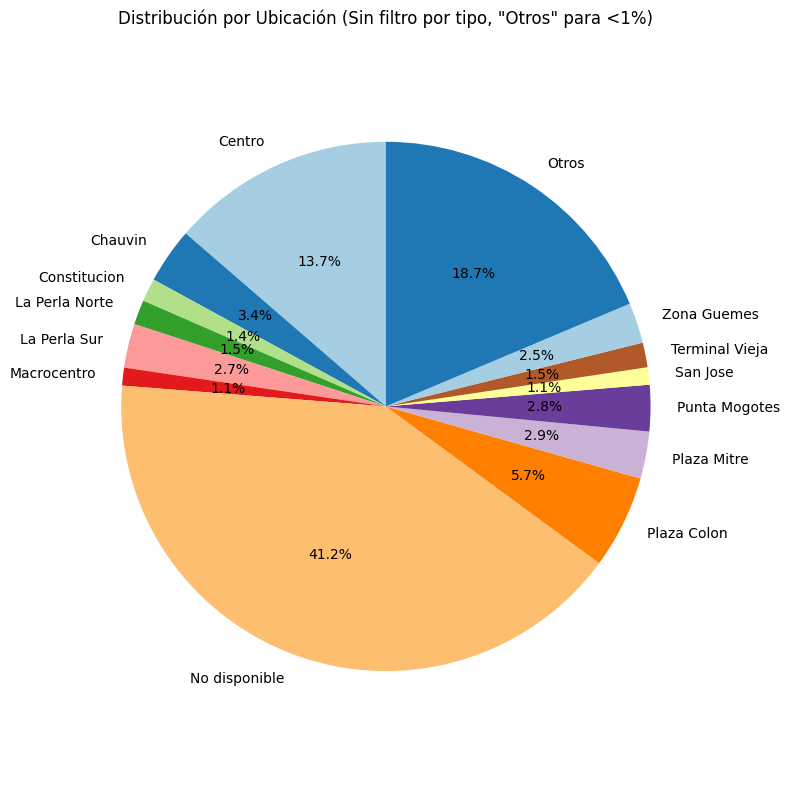

In [111]:
# Agrupo todo el df por 'BARRIO' y cuento la cantidad de filas en cada barrio
cantidad_por_ubicacion = df.groupby('BARRIO').size().reset_index(name='cantidad')

# Calculo el total sumando todas las cantidades
total = cantidad_por_ubicacion['cantidad'].sum()

# Calculo el porcentaje que representa cada barrio
cantidad_por_ubicacion['porcentaje'] = (cantidad_por_ubicacion['cantidad'] / total) * 100

# Filtrado de barrios con porcentaje menor al 1%
df_otros = cantidad_por_ubicacion[cantidad_por_ubicacion['porcentaje'] < 1]

# Sumo las cantidades de esos barrios pequeños
otros_total = df_otros['cantidad'].sum()

# Creo fila para "Otros"
otros_fila = pd.DataFrame({'BARRIO': ['Otros'], 'cantidad': [otros_total]})

# Concateno solo los barrios con >= 1% con la fila "Otros"
df_filtrado = pd.concat([cantidad_por_ubicacion[cantidad_por_ubicacion['porcentaje'] >= 1], otros_fila], ignore_index=True)

# Gráfico circular
plt.figure(figsize=(8, 8))
plt.pie(df_filtrado['cantidad'], labels=df_filtrado['BARRIO'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribución por Ubicación (Sin filtro por tipo, "Otros" para <1%)')
plt.axis('equal')
plt.tight_layout()
plt.show()


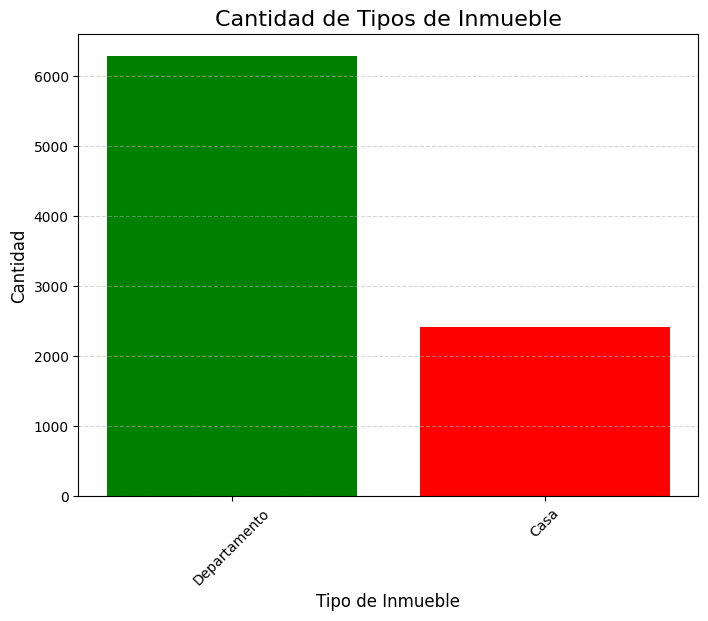

In [ ]:

# Cantidad de inmueble por tipo
tipo_counts = df['TIPO'].value_counts()

# Creo grafico de barras con matplotlib
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.bar(tipo_counts.index, tipo_counts.values, color=['green', 'red'])

# Añadir título y etiquetas
ax.set_title('Cantidad de Tipos de Inmueble', fontsize=16)
ax.set_xlabel('Tipo de Inmueble', fontsize=12)
ax.set_ylabel('Cantidad', fontsize=12)

ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Rejilla para el eje y 

# Rotp las etiquetas del eje X a 45 grados
plt.xticks(rotation=45)
# Mostrar el gráfico
plt.show()

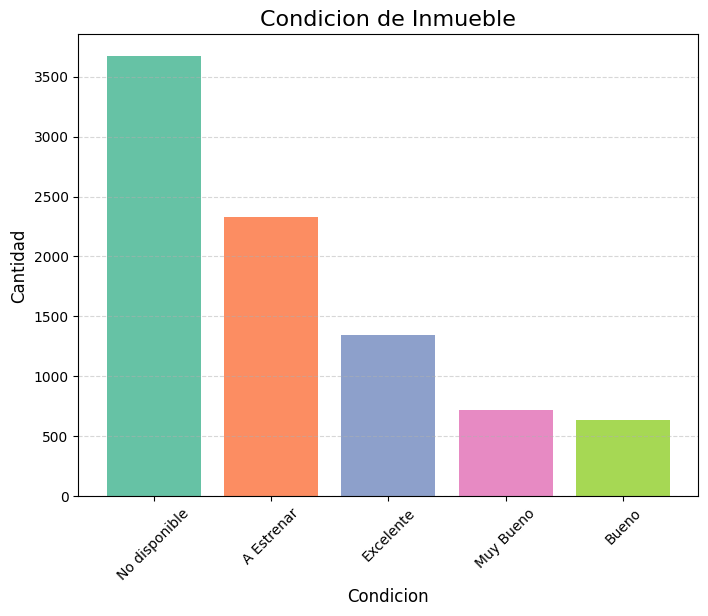

In [113]:
#UNIVARIABLE
# Cantidad de inmueble por tipo
tipo_counts = df['CONDICION'].value_counts()
palette = sns.color_palette("Set2", n_colors=len(tipo_counts))
# Creo grafico de barras con matplotlib
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.bar(tipo_counts.index, tipo_counts.values, color=palette)

# Añadir título y etiquetas
ax.set_title('Condicion de Inmueble', fontsize=16)
ax.set_xlabel('Condicion', fontsize=12)
ax.set_ylabel('Cantidad', fontsize=12)

ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Rejilla para el eje y 

# Rotp las etiquetas del eje X a 45 grados
plt.xticks(rotation=45)
# Mostrar el gráfico
plt.show()

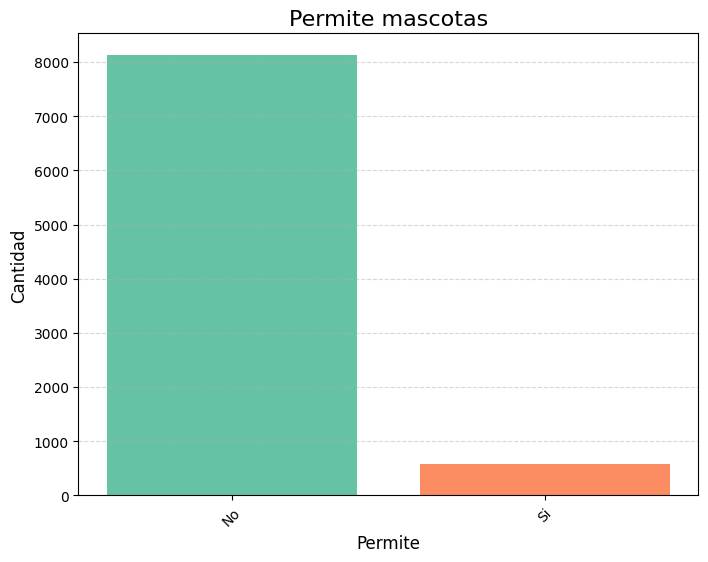

In [ ]:
# Cantidad de inmueble por tipo
tipo_counts = df['PERMITE_MASCOTAS'].value_counts()
palette = sns.color_palette("Set2", n_colors=len(tipo_counts))
# Creo grafico de barras con matplotlib
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.bar(tipo_counts.index, tipo_counts.values, color=palette)

# Añadir título y etiquetas
ax.set_title('Permite mascotas', fontsize=16)
ax.set_xlabel('Permite', fontsize=12)
ax.set_ylabel('Cantidad', fontsize=12)

ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Rejilla para el eje y 

# Rotp las etiquetas del eje X a 45 grados
plt.xticks(rotation=45)
# Mostrar el gráfico
plt.show()

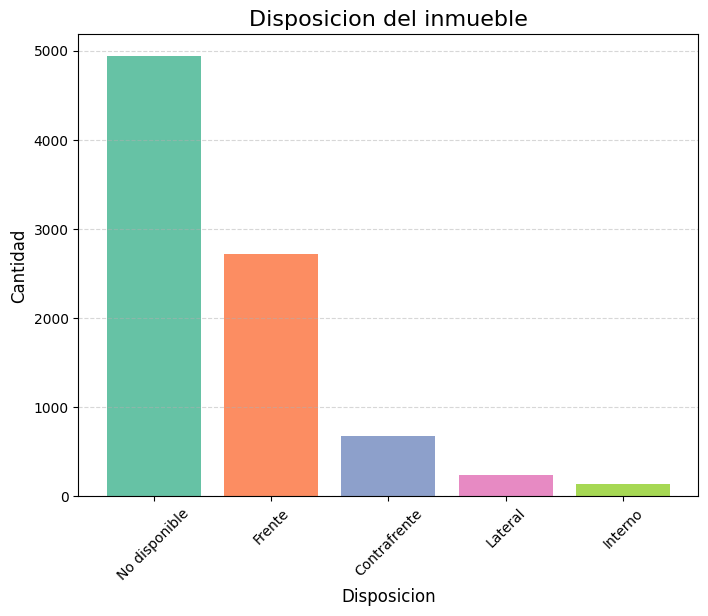

In [115]:
# Cantidad de inmueble por tipo
tipo_counts = df['DISPOSICION'].value_counts()
palette = sns.color_palette("Set2", n_colors=len(tipo_counts))
# Creo grafico de barras con matplotlib
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.bar(tipo_counts.index, tipo_counts.values, color=palette)

# Añadir título y etiquetas
ax.set_title('Disposicion del inmueble', fontsize=16)
ax.set_xlabel('Disposicion', fontsize=12)
ax.set_ylabel('Cantidad', fontsize=12)

ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Rejilla para el eje y 

# Rotp las etiquetas del eje X a 45 grados
plt.xticks(rotation=45)
# Mostrar el gráfico
plt.show()

## 3.2 - Análisis Univariado

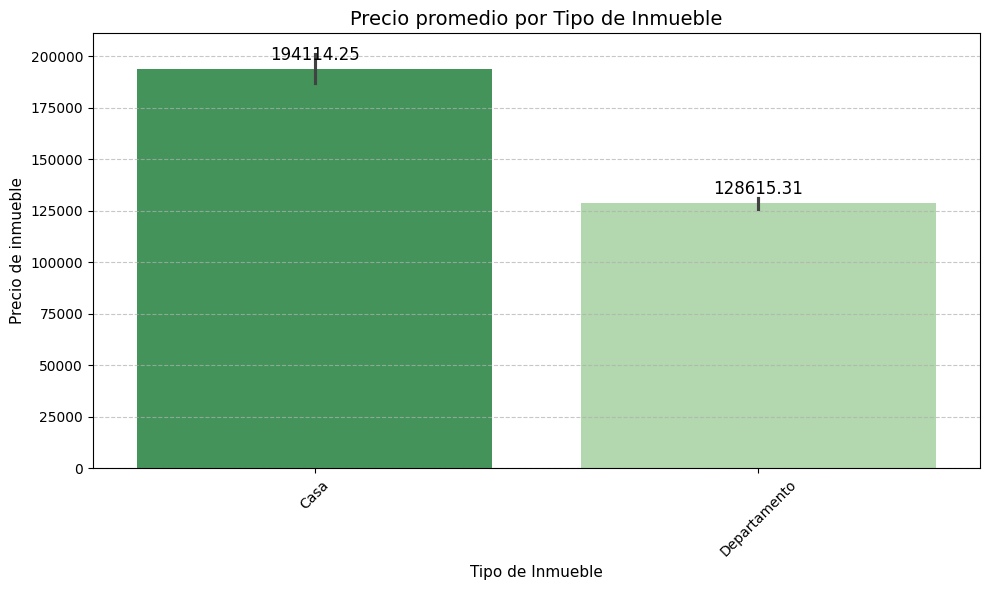

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordeno alfabéticamente las categorías del eje x
order = sorted(df['TIPO'].unique())

# Creo la figura para un solo gráfico
plt.figure(figsize=(10, 6))

# Gráfico de barras con seaborn
sns.barplot(x='TIPO', y='PRECIO', data=df, hue='TIPO', palette='Greens', order=order)

# Título y etiquetas
plt.title('Precio promedio por Tipo de Inmueble', fontsize=14)
plt.xlabel('Tipo de Inmueble', fontsize=11)
plt.ylabel('Precio de inmueble', fontsize=11)

# Activar grid solo en eje Y
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Rotar etiquetas del eje X
plt.xticks(rotation=45)

# Añadir valores encima de cada barra
ax = plt.gca()  # Obtener el eje actual
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black',
                xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()


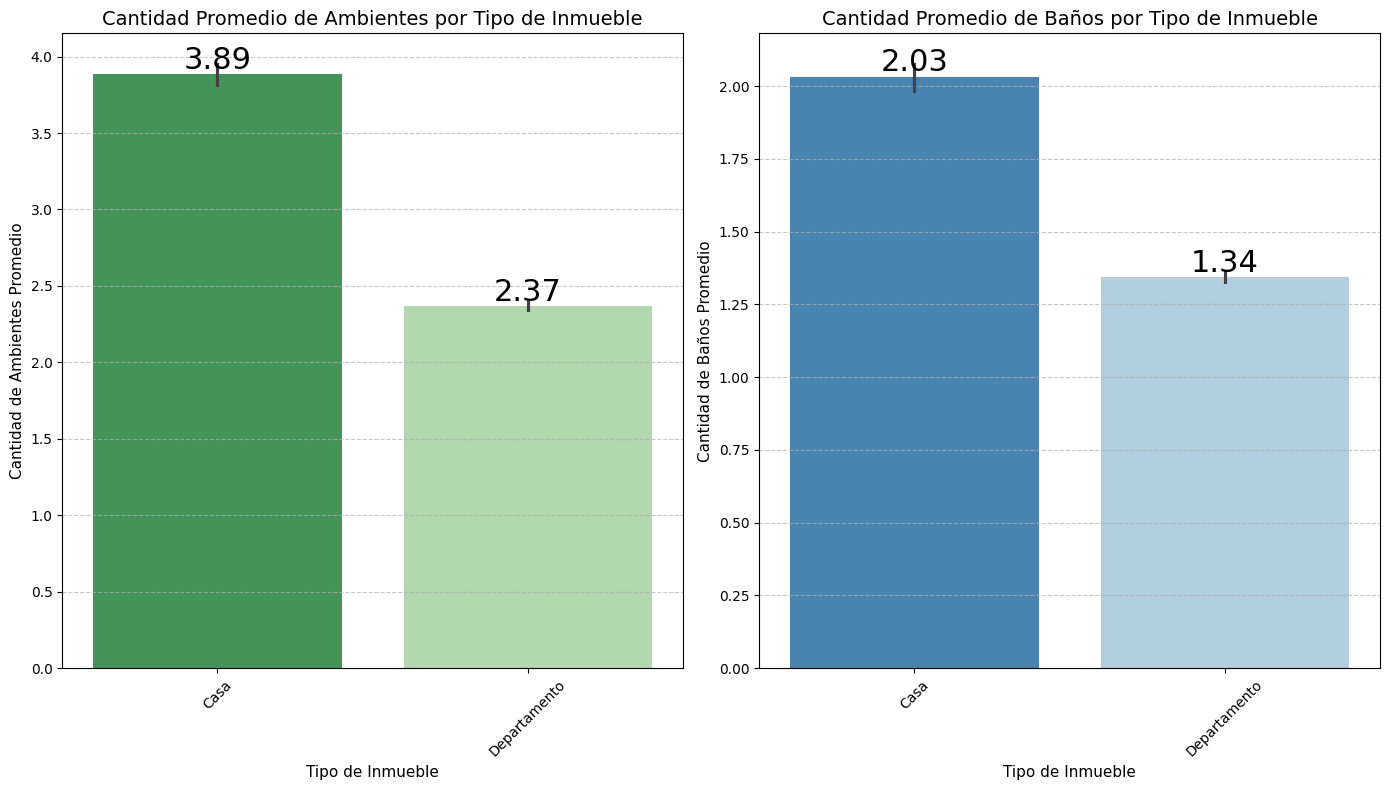

In [117]:
# Creo la figura y los subgráficos (subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))  # 1 fila con 2 columnas

# Ordeno alfabéticamente eje x
order = sorted(df['TIPO'])  

# Gráfico de barras para cantidad_ambientes_caracteristicas
sns.barplot(x='TIPO', y='CANTIDAD_AMBIENTES', data=df, hue='TIPO', palette='Greens', ax=axes[0], order=order)
#con hue discrimino con un color las diferentes categorias de tipo; uso paleta de greens(verdes); con ax=axes(0) inserto 1er grafico enl 1er subgrafico  
axes[0].set_title('Cantidad Promedio de Ambientes por Tipo de Inmueble', fontsize=14)
axes[0].set_xlabel('Tipo de Inmueble', fontsize=11)
axes[0].set_ylabel('Cantidad de Ambientes Promedio', fontsize=11)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)
#Al 1er subgrafico le activo cuadricula/grid solo a eje Y con un determinado estilo de linea y transparencia de 30% (0,7 opaco)
axes[0].tick_params(axis='x', rotation=45)  # Rotar etiquetas del eje X

# Añado el valor promedio encima de cada barra, definiendo su valor con 2 decimales,sus coordenadas en plano, y luego su alineacion (horizonal y vertical
#y con xytext doy un offset para que no quedpegado a la barra. textcoords='offset points' indica que el offset es relativo a la posición (x, y) y no en coordenadas del gráfico.
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', fontsize=22, color='black', xytext=(0, 10), textcoords='offset points')

# Repito gráfico de barras para cantidad_banios_caracteristicas
sns.barplot(x='TIPO', y='CANTIDAD_BANIOS', data=df, hue='TIPO', palette='Blues', ax=axes[1], order=order)
axes[1].set_title('Cantidad Promedio de Baños por Tipo de Inmueble', fontsize=14)
axes[1].set_xlabel('Tipo de Inmueble', fontsize=11)
axes[1].set_ylabel('Cantidad de Baños Promedio', fontsize=11)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)  # Rotar etiquetas del eje X

# Repito lo de añadir el valor promedio encima de cada barra
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', fontsize=22, color='black', xytext=(0, 10), textcoords='offset points')

# Grafico
plt.tight_layout()  # Ajusto automáticamente los subgráficos
plt.show()

Distribucion de departamentos por barrio

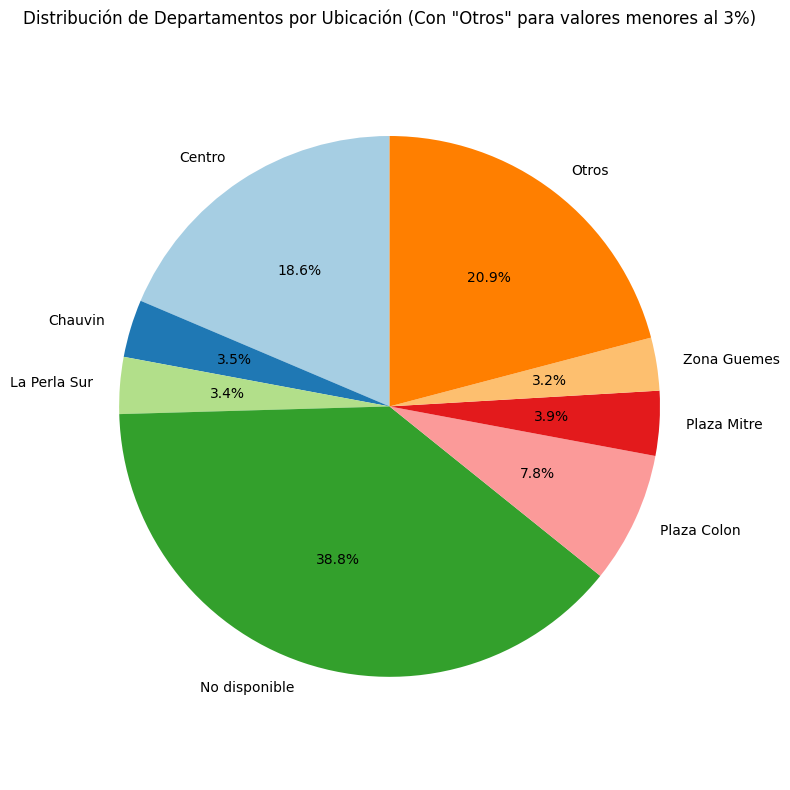

In [118]:
# filtro departamentos, buscando la palabra Departamento, sin considerar las mayusculas o minusculas (case=false), considerando valores NaN como falso
df_departamentos = df[df['TIPO'].str.contains('DEPARTAMENTO', case=False, na=False)]

# Cuento la cantidad de departamentos por ubicación
cantidad_departamentos_ubicacion = df_departamentos.groupby('BARRIO').size().reset_index(name='cantidad_departamentos')
#agrupo y cuento filas de c/u de los grupos (tendria una serie), pero luego con reset_index genero una columna (deja de ser indice UBICACION),y
#asigno nombre 'cantidad_departamentos' a la columna de valores que tenía la Serie. Al final tendria:index(0,1,2..),ubicacion y cant-deptos(antes valores de seie)

# Calculo el total de deptos sumandolos
total_departamentos = cantidad_departamentos_ubicacion['cantidad_departamentos'].sum()

#calculo %
cantidad_departamentos_ubicacion['porcentaje'] = (cantidad_departamentos_ubicacion['cantidad_departamentos'] / total_departamentos) * 100

#Discrimino a los menores de 3%, creando un df filtrando otro
df_otros_departamentos = cantidad_departamentos_ubicacion[cantidad_departamentos_ubicacion['porcentaje'] < 3]
#Calculo cantidad de los que son menores a 3 %
otros_categorias_departamentos = df_otros_departamentos['cantidad_departamentos'].sum()

# Creo un nuevo dataframe que posee una columna llamada ubicacion con valor Otros, y columna cant deptos, el valor calculado antes
otros_row = pd.DataFrame({'BARRIO': ['Otros'], 'cantidad_departamentos': [otros_categorias_departamentos]})
#concateno, añado la fila de df otros_row al df con valores >= 3 %, y reinicio index
df_departamentos_filtrados_con_otros = pd.concat([cantidad_departamentos_ubicacion[cantidad_departamentos_ubicacion['porcentaje'] >= 3], otros_row], ignore_index=True)

# Gráfico circular para los departamentos
plt.figure(figsize=(8, 8))
plt.pie(df_departamentos_filtrados_con_otros['cantidad_departamentos'], labels=df_departamentos_filtrados_con_otros['BARRIO'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
#defino valores, etiquetas, formato %1.1f%% (un decimal y simbolo%),startangle define el ángulo (en grados) desde donde inicia el primer sector del gráfico.
plt.title('Distribución de Departamentos por Ubicación (Con "Otros" para valores menores al 3%)')
plt.axis('equal')  # Para hacer el gráfico circular
plt.tight_layout()  # Ajustar el espaciado
plt.show()

Distribucion de casas por barrio

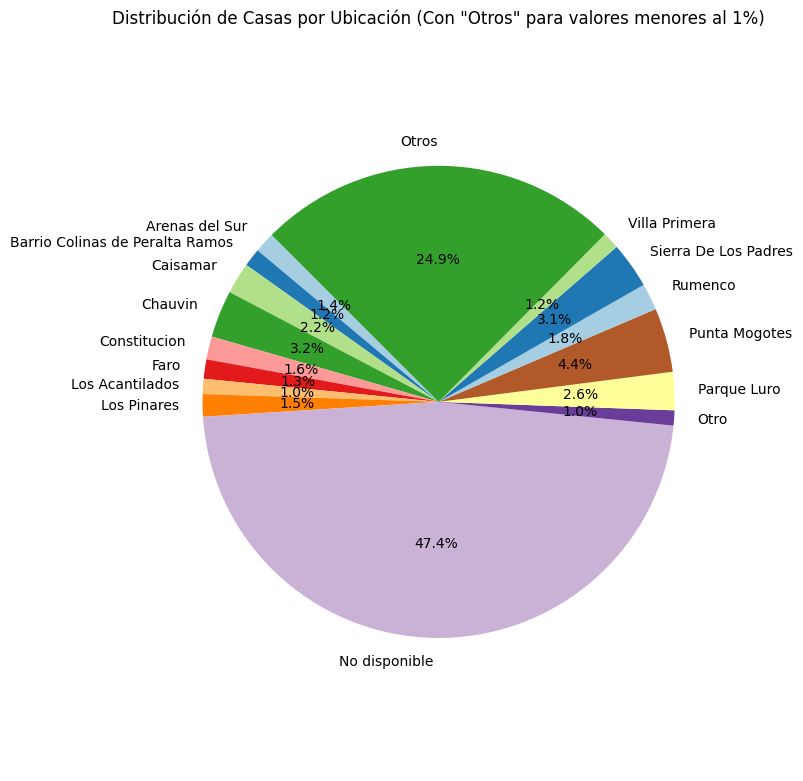

In [119]:
#REPITO SECUENCIa anterior para casas, consideransdo 1% para otros
df_casas = df[df['TIPO'].str.contains('Casa', case=False, na=False)]


cantidad_casas_ubicacion = df_casas.groupby('BARRIO').size().reset_index(name='cantidad_casas')


total_casas = cantidad_casas_ubicacion['cantidad_casas'].sum()


cantidad_casas_ubicacion['porcentaje'] = (cantidad_casas_ubicacion['cantidad_casas'] / total_casas) * 100
df_otros_casas = cantidad_casas_ubicacion[cantidad_casas_ubicacion['porcentaje'] < 1]
otros_categorias_casas = df_otros_casas['cantidad_casas'].sum()


otros_row_casas = pd.DataFrame({'BARRIO': ['Otros'], 'cantidad_casas': [otros_categorias_casas]})
df_casas_filtradas_con_otros = pd.concat([cantidad_casas_ubicacion[cantidad_casas_ubicacion['porcentaje'] >= 1], otros_row_casas], ignore_index=True)


plt.figure(figsize=(8, 8))
plt.pie(df_casas_filtradas_con_otros['cantidad_casas'], labels=df_casas_filtradas_con_otros['BARRIO'], autopct='%1.1f%%', startangle=135, colors=plt.cm.Paired.colors)
plt.title('Distribución de Casas por Ubicación (Con "Otros" para valores menores al 1%)')
plt.axis('equal')  
plt.tight_layout() 
plt.show()

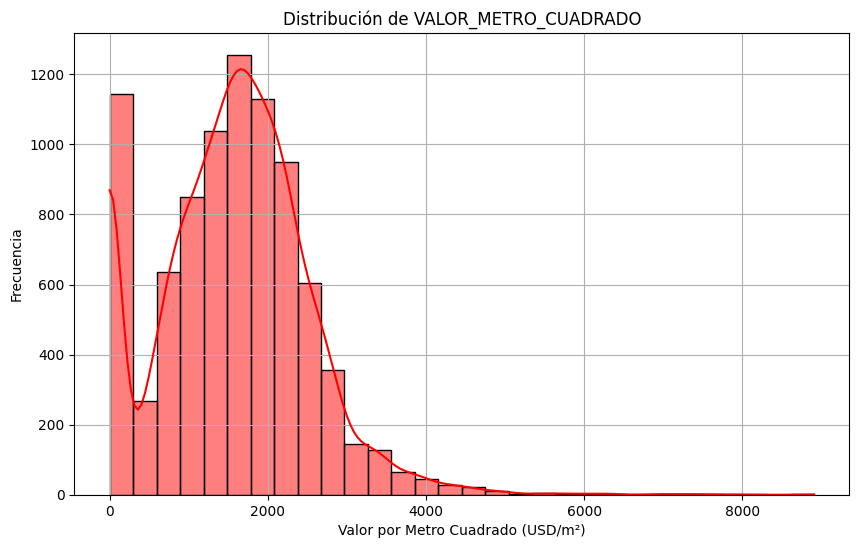

In [120]:
plt.figure(figsize=(10,6))

# Histograma con KDE integrado
sns.histplot(df['VALOR_METRO_CUADRADO'], kde=True, bins=30, color='red')

plt.title('Distribución de VALOR_METRO_CUADRADO')
plt.xlabel('Valor por Metro Cuadrado (USD/m²)')
plt.ylabel('Frecuencia')
plt.grid(True)

plt.show()



## 3.3 - Análisis Bivariado

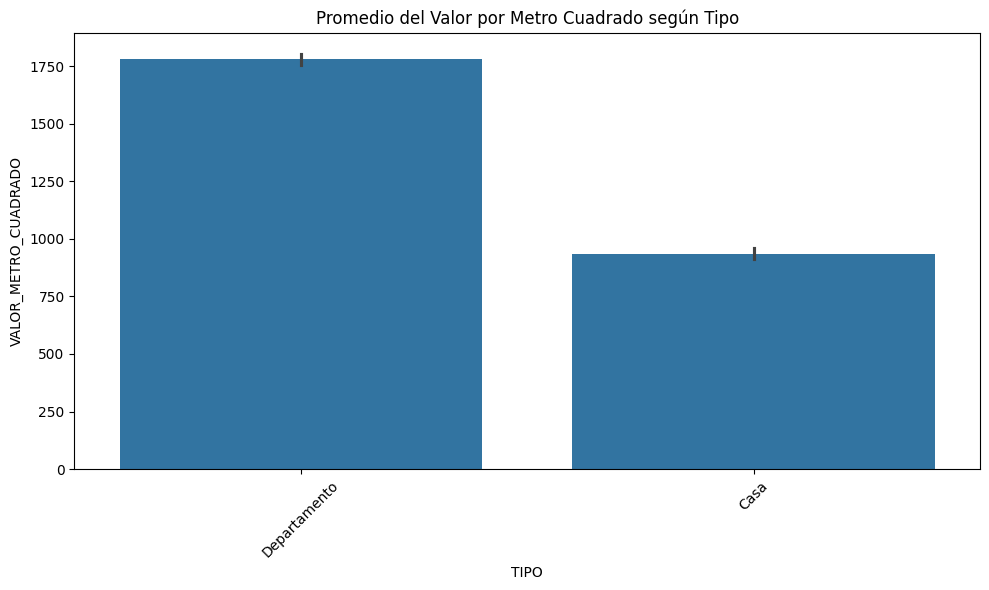

In [121]:
#sns.barplot calcula internamente la media (promedio) de la variable en el eje "y" para cada categoría en el eje "x# y dibuja barras con esa
#media.
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='TIPO', y='VALOR_METRO_CUADRADO')
plt.title('Promedio del Valor por Metro Cuadrado según Tipo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

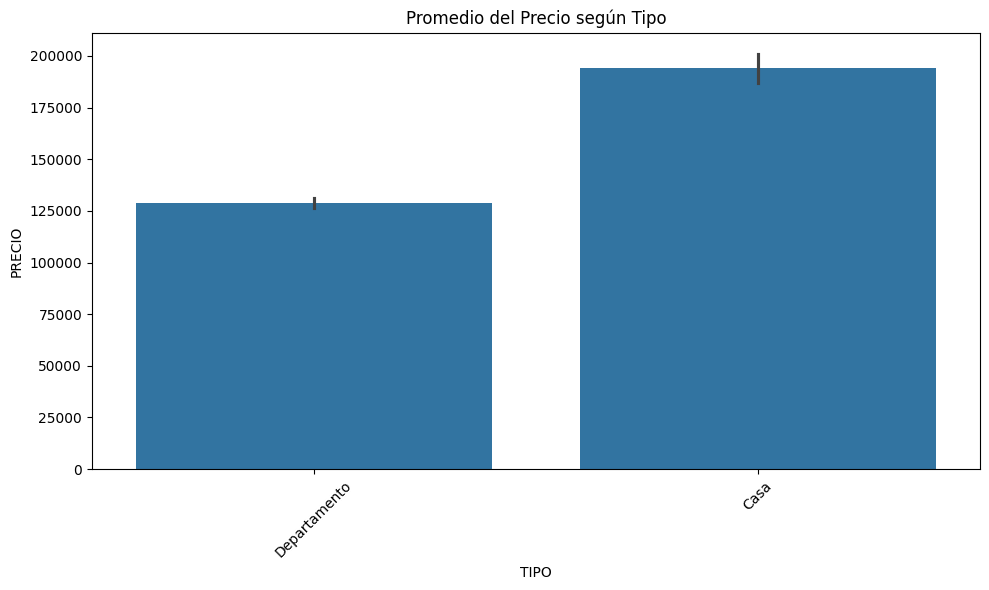

In [122]:

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='TIPO', y='PRECIO')
plt.title('Promedio del Precio según Tipo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\barba\AppData\Local\Temp\ipykernel_3872\2361613705.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top_10, x='BARRIO', y='PRECIO', order=top_10_barrios, ci=None)


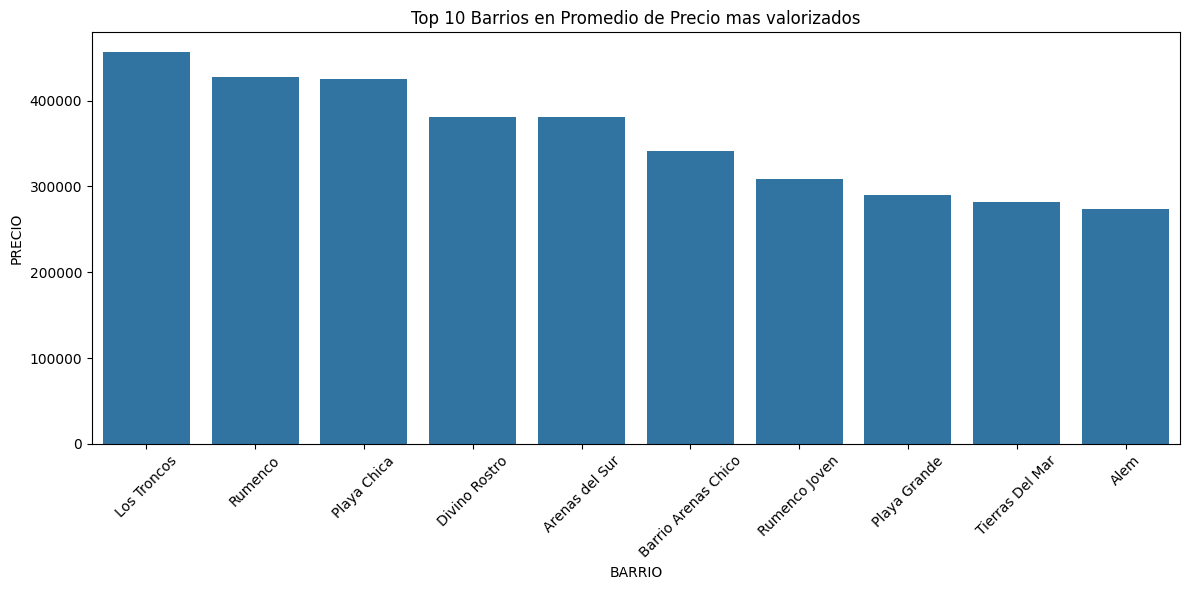

In [123]:
promedios = df.groupby('BARRIO')['PRECIO'].mean()
top_10_barrios = promedios.sort_values(ascending=False).head(10).index
df_top_10 = df[df['BARRIO'].isin(top_10_barrios)]
 
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_10, x='BARRIO', y='PRECIO', order=top_10_barrios, ci=None)
plt.title('Top 10 Barrios en Promedio de Precio mas valorizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\barba\AppData\Local\Temp\ipykernel_3872\3630134915.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top_10, x='BARRIO', y='VALOR_METRO_CUADRADO', order=orden_invertido, ci=None)


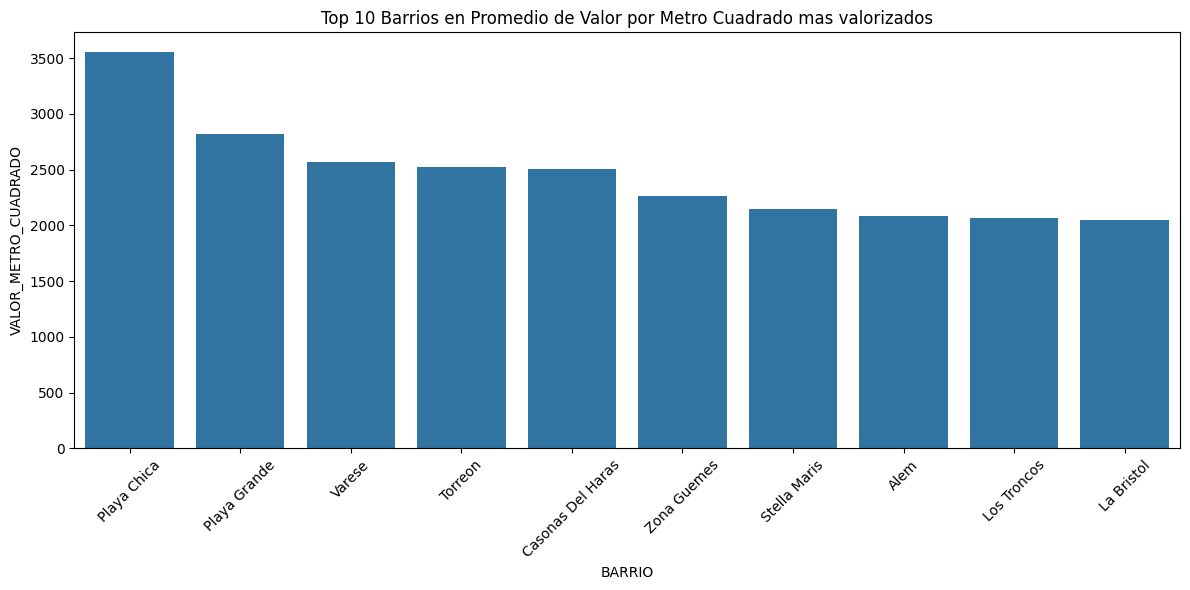

In [124]:
promedios = df.groupby('BARRIO')['VALOR_METRO_CUADRADO'].mean()

top_10_barrios_mas = promedios.sort_values(ascending=False).head(10)


df_top_10 = df[df['BARRIO'].isin(top_10_barrios_mas.index)]

orden_invertido = top_10_barrios_mas.sort_values(ascending=False).index


plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_10, x='BARRIO', y='VALOR_METRO_CUADRADO', order=orden_invertido, ci=None)
plt.title('Top 10 Barrios en Promedio de Valor por Metro Cuadrado mas valorizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



C:\Users\barba\AppData\Local\Temp\ipykernel_3872\1847617069.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top_10, x='BARRIO', y='PRECIO', order=orden_invertido, ci=None)


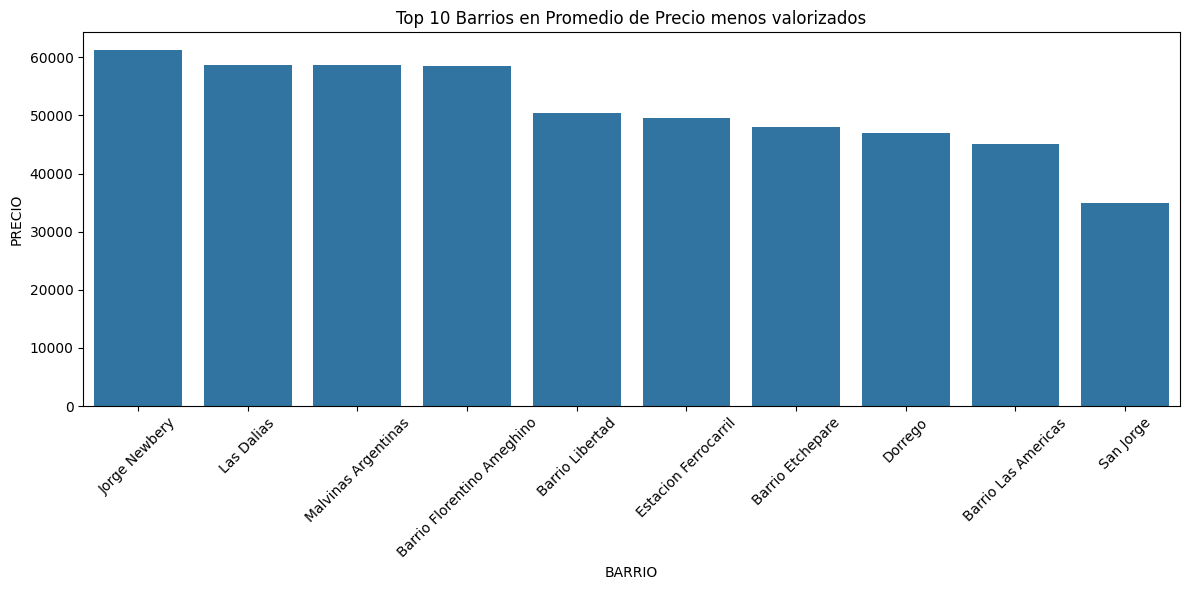

In [125]:

promedios = df.groupby('BARRIO')['PRECIO'].mean()
top_10_barrios_menos = promedios.sort_values(ascending=True).head(10)
df_top_10 = df[df['BARRIO'].isin(top_10_barrios_menos.index)]
orden_invertido = top_10_barrios_menos.sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_10, x='BARRIO', y='PRECIO', order=orden_invertido, ci=None)
plt.title('Top 10 Barrios en Promedio de Precio menos valorizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\barba\AppData\Local\Temp\ipykernel_3872\541449779.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top_10, x='BARRIO', y='VALOR_METRO_CUADRADO', order=orden_invertido, ci=None)


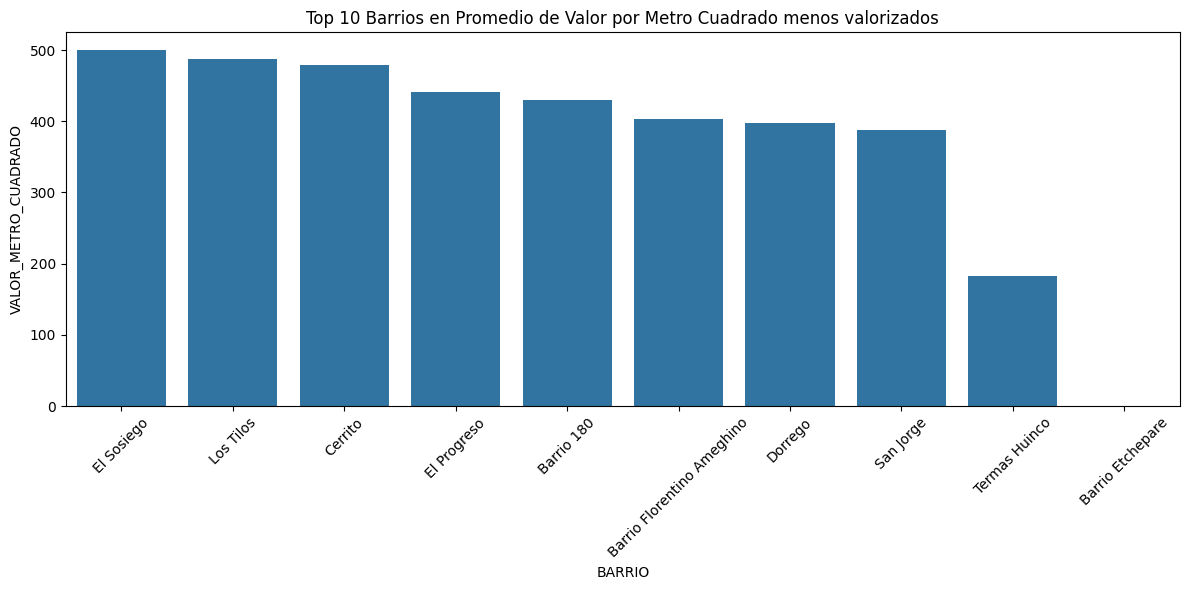

In [126]:
promedios = df.groupby('BARRIO')['VALOR_METRO_CUADRADO'].mean()

top_10_barrios_menos = promedios.sort_values(ascending=True).head(10)


df_top_10 = df[df['BARRIO'].isin(top_10_barrios_menos.index)]

orden_invertido = top_10_barrios_menos.sort_values(ascending=False).index


plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_10, x='BARRIO', y='VALOR_METRO_CUADRADO', order=orden_invertido, ci=None)
plt.title('Top 10 Barrios en Promedio de Valor por Metro Cuadrado menos valorizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



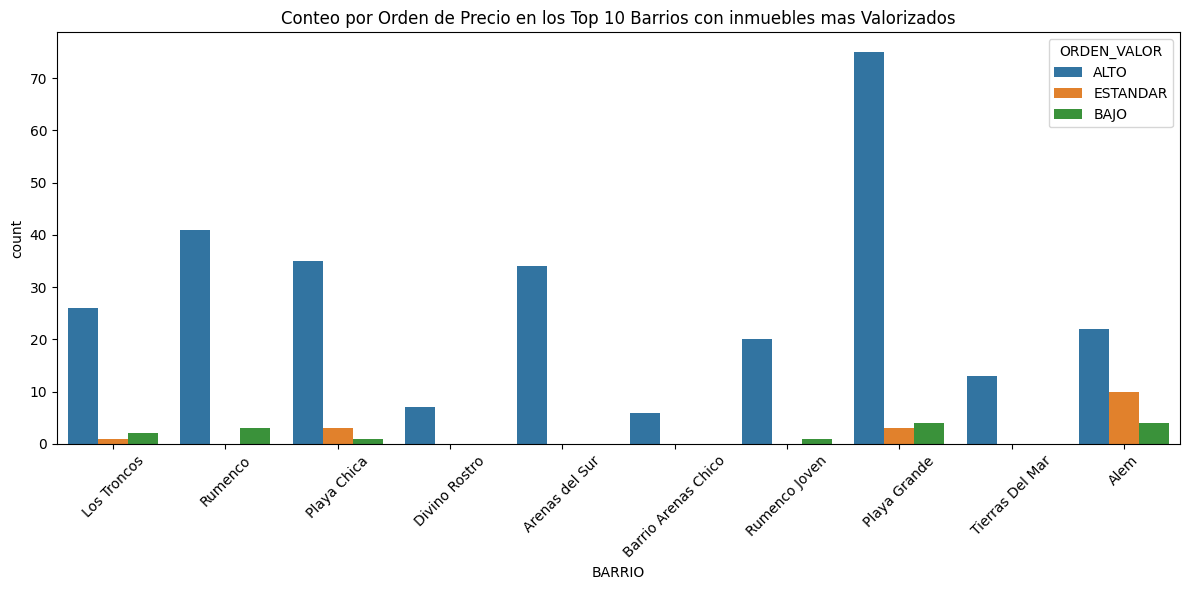

In [127]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['BARRIO'].isin(top_10_barrios)],
              x='BARRIO',
              hue='ORDEN_VALOR',
              order=top_10_barrios)

plt.title('Conteo por Orden de Precio en los Top 10 Barrios con inmuebles mas Valorizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




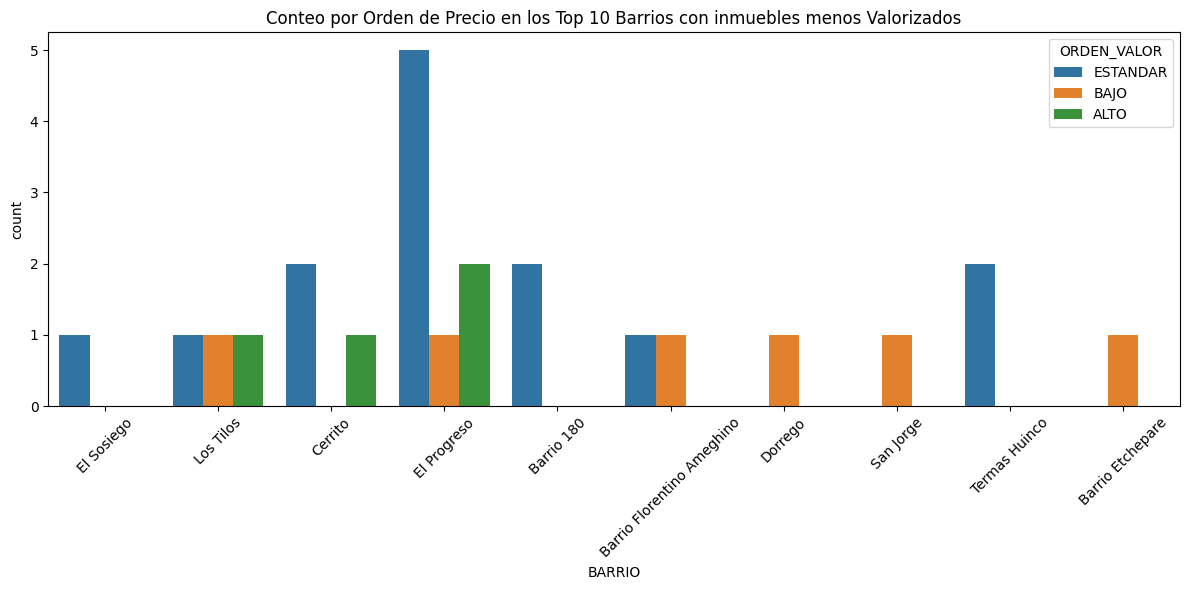

In [128]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['BARRIO'].isin(top_10_barrios_menos.index)],
              x='BARRIO',
              hue='ORDEN_VALOR',
              order=top_10_barrios_menos.sort_values(ascending=False).index)

plt.title('Conteo por Orden de Precio en los Top 10 Barrios con inmuebles menos Valorizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


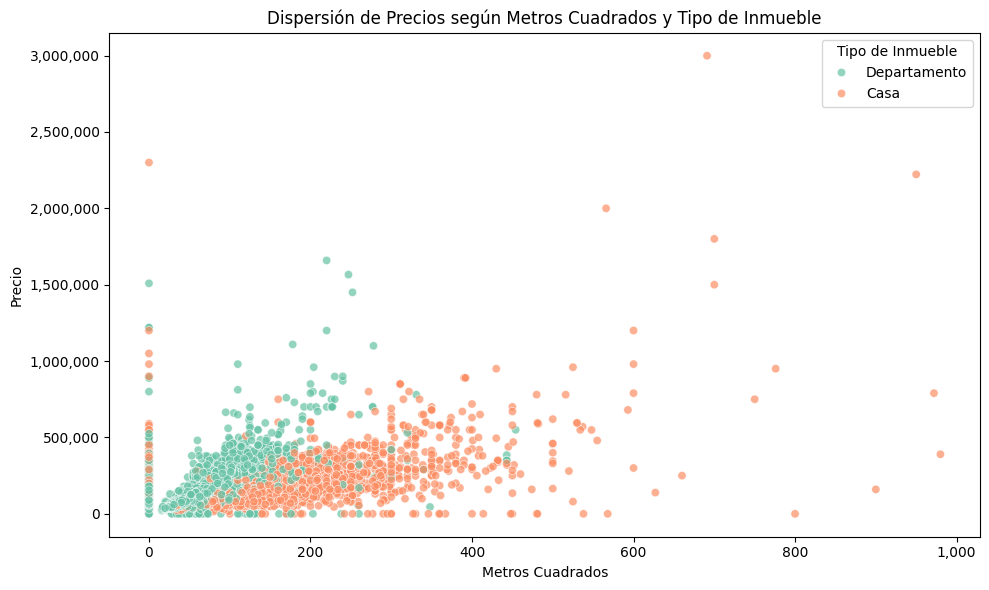

In [129]:
df['PRECIO_REAL'] = df['PRECIO']

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='METROS_CUADRADOS', y='PRECIO_REAL', hue='TIPO', palette='Set2', alpha=0.7)

plt.title('Dispersión de Precios según Metros Cuadrados y Tipo de Inmueble')
plt.xlabel('Metros Cuadrados')
plt.ylabel('Precio')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.legend(title='Tipo de Inmueble', loc='best')
plt.tight_layout()
plt.show()


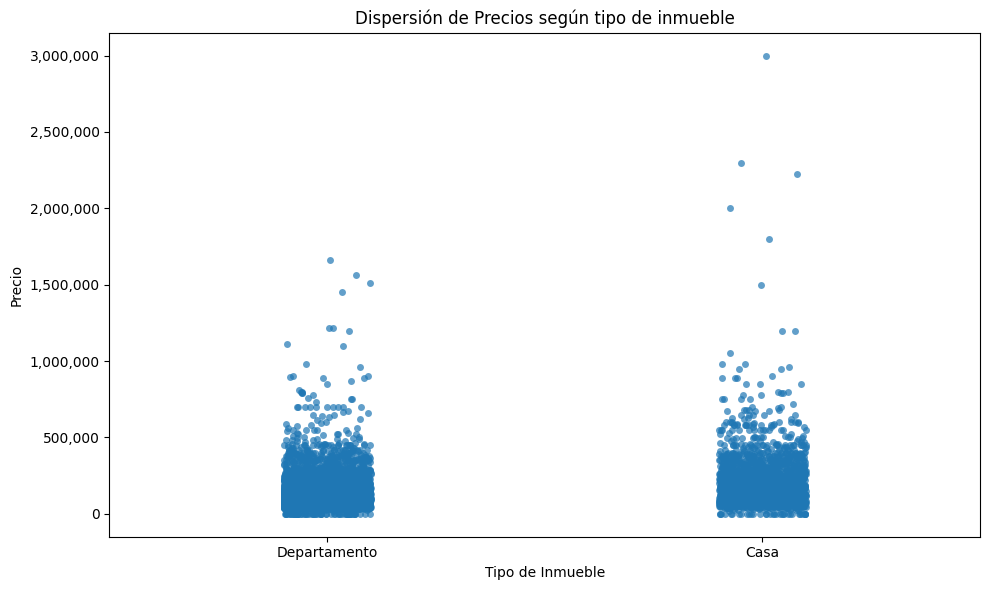

In [130]:
df['PRECIO_REAL'] = df['PRECIO']

plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='TIPO', y='PRECIO_REAL', jitter=True, alpha=0.7)

plt.title('Dispersión de Precios según tipo de inmueble')
plt.xlabel('Tipo de Inmueble')
plt.ylabel('Precio')

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

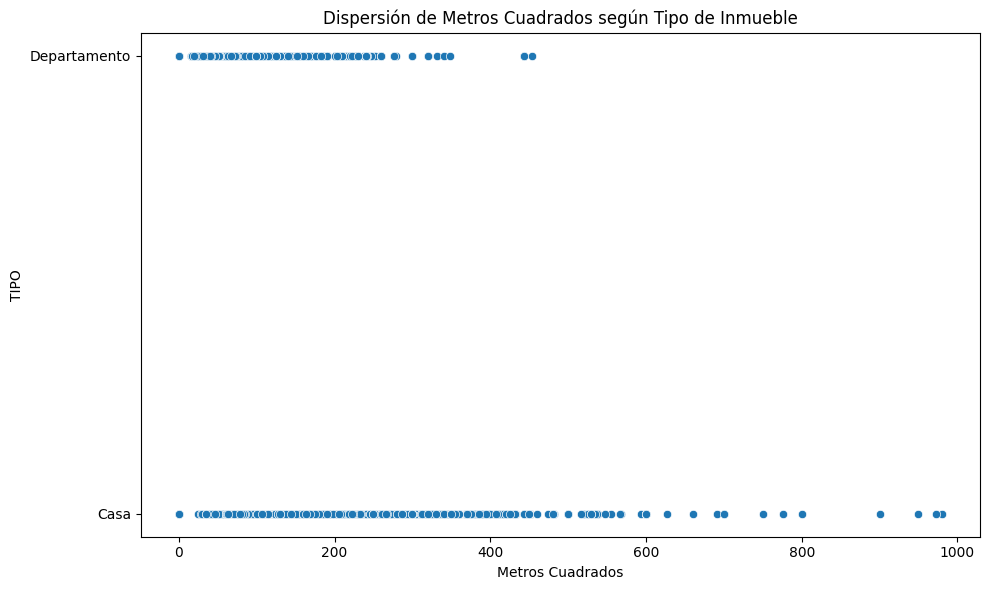

In [131]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='METROS_CUADRADOS', y='TIPO')
plt.title('Dispersión de Metros Cuadrados según Tipo de Inmueble')
plt.xlabel('Metros Cuadrados')
plt.tight_layout()
plt.show()

C:\Users\barba\AppData\Local\Temp\ipykernel_3872\518667233.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_barrios_df, x='BARRIO', y='CANTIDAD', palette='viridis')


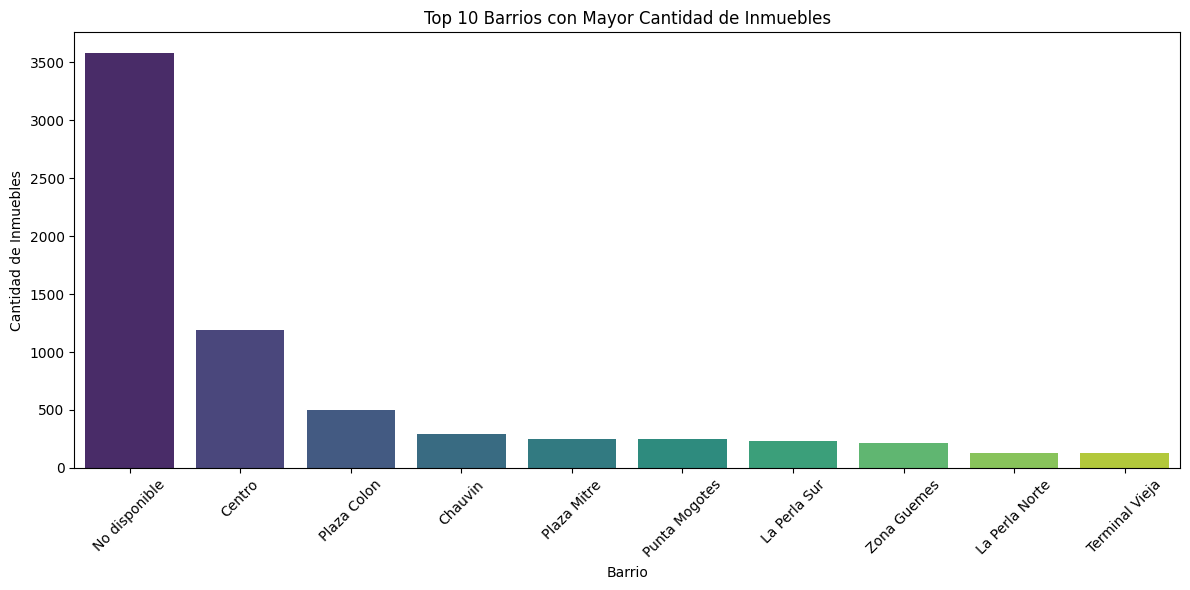

In [132]:
top_barrios = df['BARRIO'].value_counts().nlargest(10)

top_barrios_df = top_barrios.reset_index()
top_barrios_df.columns = ['BARRIO', 'CANTIDAD']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_barrios_df, x='BARRIO', y='CANTIDAD', palette='viridis')
plt.title('Top 10 Barrios con Mayor Cantidad de Inmuebles')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de Inmuebles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


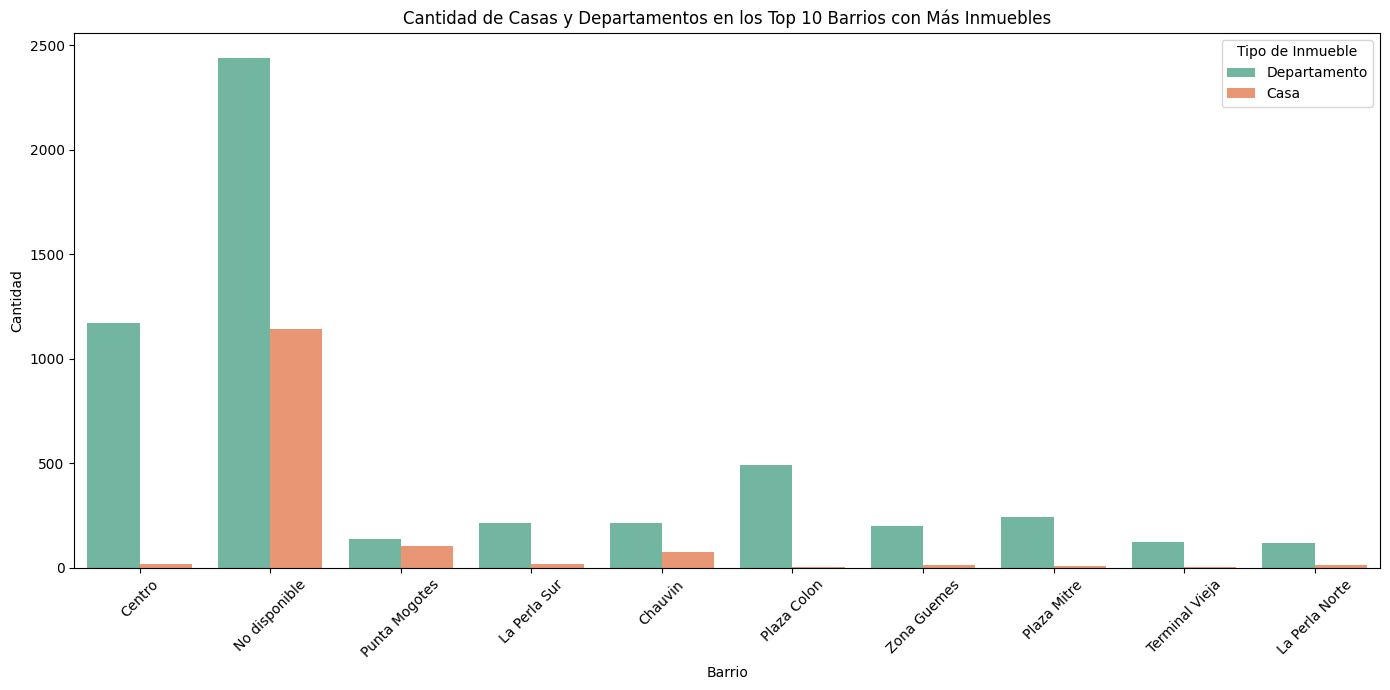

In [133]:
df_filtrado = df[df['TIPO'].isin(['Departamento', 'Casa'])]
top_barrios = df_filtrado['BARRIO'].value_counts().nlargest(10).index
df_top_barrios = df_filtrado[df_filtrado['BARRIO'].isin(top_barrios)]


plt.figure(figsize=(14, 7))
sns.countplot(data=df_top_barrios, x='BARRIO', hue='TIPO', palette='Set2')
plt.title('Cantidad de Casas y Departamentos en los Top 10 Barrios con Más Inmuebles')
plt.xlabel('Barrio')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Inmueble')
plt.tight_layout()
plt.show()


C:\Users\barba\AppData\Local\Temp\ipykernel_3872\2494748137.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_antiguedad.values, y=top10_antiguedad.index, palette='magma')


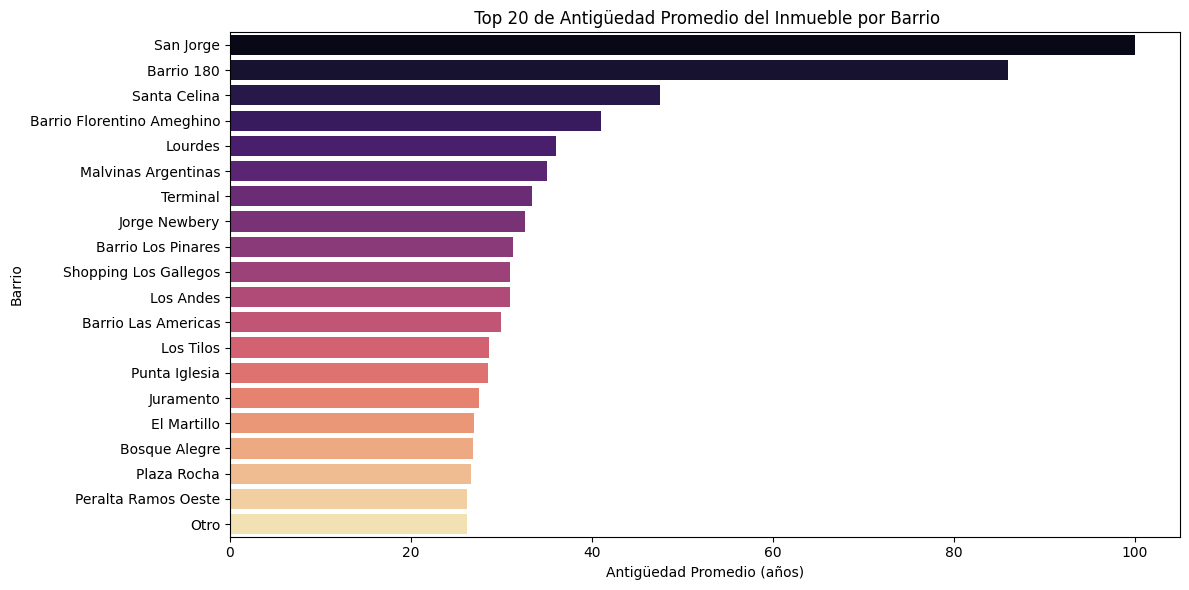

In [134]:
df['ANTIGUEDAD'] = pd.to_numeric(df['ANTIGUEDAD'], errors='coerce')
df_limpio = df.dropna(subset=['ANTIGUEDAD'])
antiguedad_promedio = df_limpio.groupby('BARRIO')['ANTIGUEDAD'].mean().sort_values(ascending=False)

top10_antiguedad = antiguedad_promedio.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10_antiguedad.values, y=top10_antiguedad.index, palette='magma')
plt.title(' Top 20 de Antigüedad Promedio del Inmueble por Barrio')
plt.xlabel('Antigüedad Promedio (años)')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()


C:\Users\barba\AppData\Local\Temp\ipykernel_3872\2300355613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_antiguedad.values, y=top10_antiguedad.index, palette='magma')


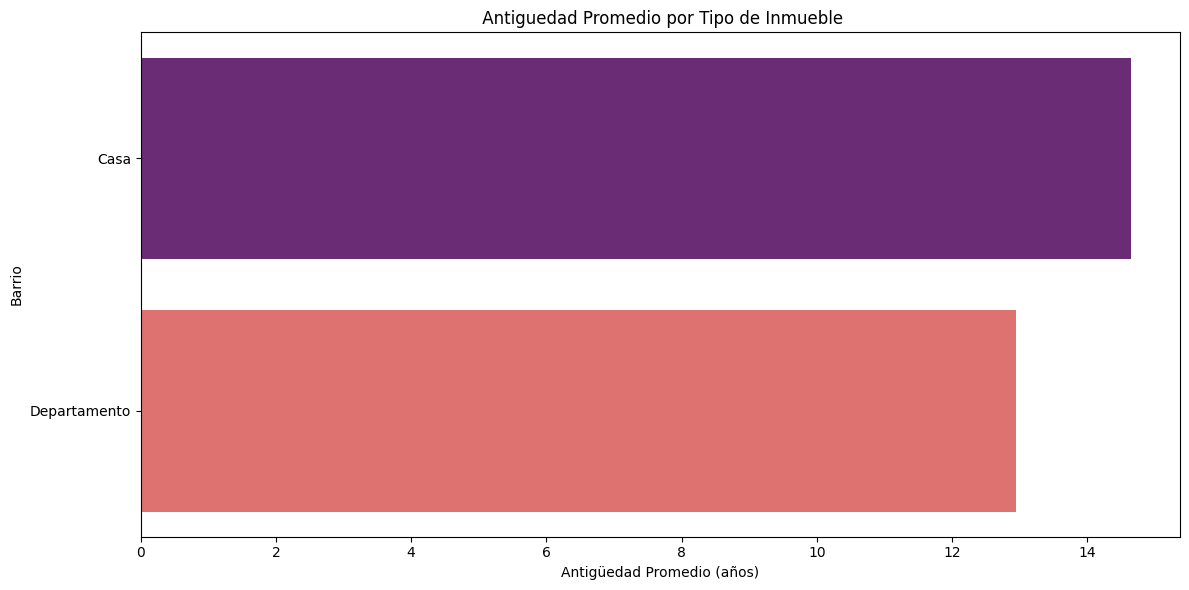

In [135]:
df['ANTIGUEDAD'] = pd.to_numeric(df['ANTIGUEDAD'], errors='coerce')
df_limpio = df.dropna(subset=['ANTIGUEDAD'])
antiguedad_promedio = df_limpio.groupby('TIPO')['ANTIGUEDAD'].mean().sort_values(ascending=False)

top10_antiguedad = antiguedad_promedio.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10_antiguedad.values, y=top10_antiguedad.index, palette='magma')
plt.title(' Antiguedad Promedio por Tipo de Inmueble')
plt.xlabel('Antigüedad Promedio (años)')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()

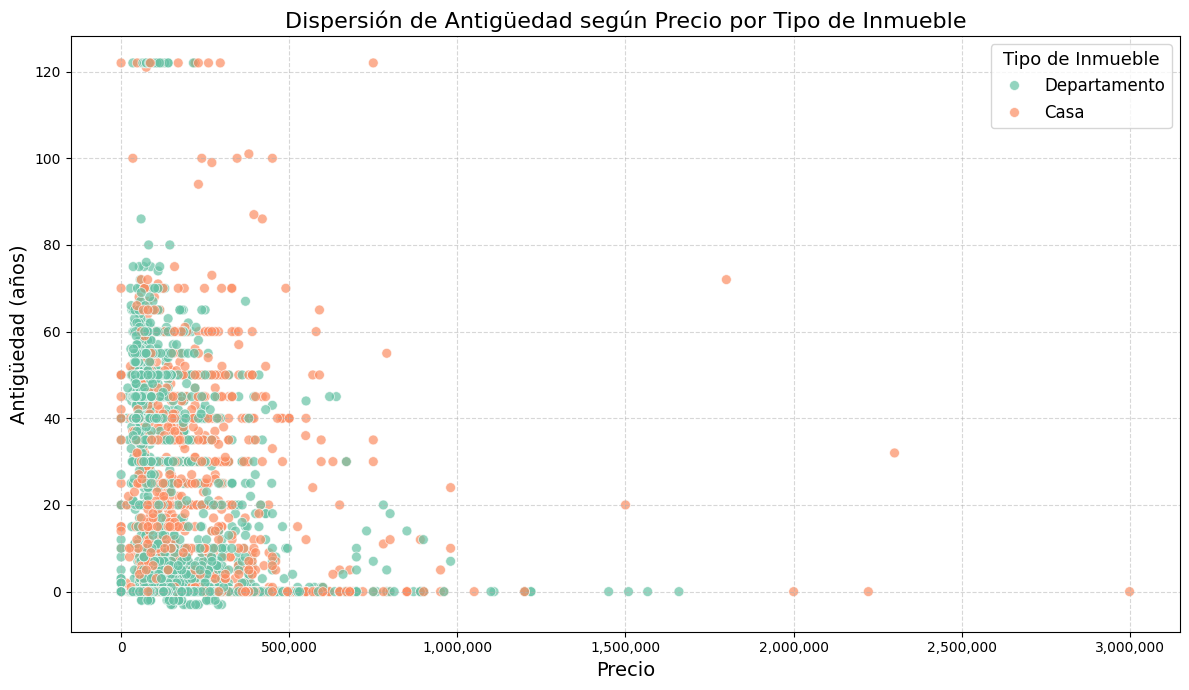

In [136]:
#BIVAARIADO

import matplotlib.ticker as mtick

plt.figure(figsize=(12, 7))

sns.scatterplot(data=df, x='PRECIO', y='ANTIGUEDAD',
                hue='TIPO', palette='Set2', alpha=0.7, s=50)

plt.title('Dispersión de Antigüedad según Precio por Tipo de Inmueble', fontsize=16)
plt.xlabel('Precio', fontsize=14)
plt.ylabel('Antigüedad (años)', fontsize=14)

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tipo de Inmueble', fontsize=12, title_fontsize=13, loc='upper right')

plt.tight_layout()
plt.show()


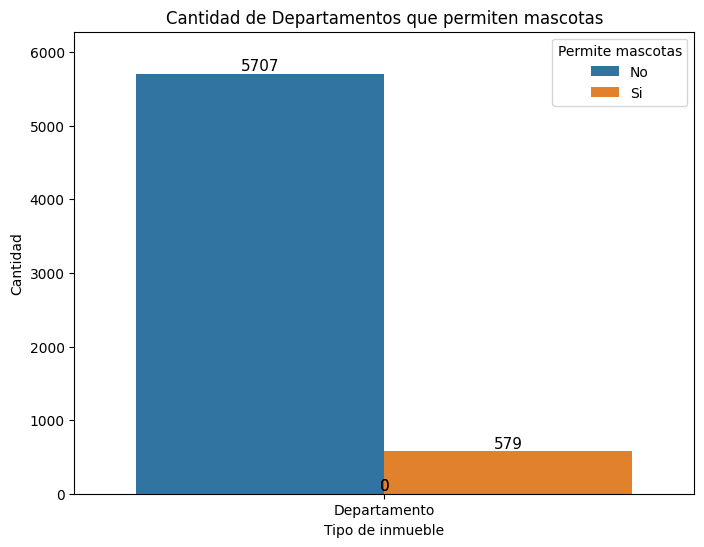

In [137]:

df['TIPO'] = df['TIPO'].str.strip().str.capitalize()  # Para que quede 'Casa' o 'Departamento' sin espacios extras
df['permite_mascotas'] = df['PERMITE_MASCOTAS'].str.strip().str.capitalize()  # 'Sí' o 'No'

# Filtro solo casas y departamentos
df_filtrado = df[df['TIPO'].isin(['Departamento'])]

# Agrupo y cuento tars convertir la serie resultante en un DataFrame con una columna llamada cantidad que contiene los conteos de size de cada agrupacion.
conteo = df_filtrado.groupby(['TIPO', 'PERMITE_MASCOTAS']).size().reset_index(name='cantidad')

# Grafico 
plt.figure(figsize=(8,6))
ax = sns.barplot(data=conteo, x='TIPO', y='cantidad', hue='PERMITE_MASCOTAS')

# Agregar etiquetas con cantidad arriba de cada barra / similar a lor realizado en aterior graf barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black')

plt.title('Cantidad de Departamentos que permiten mascotas')
plt.xlabel('Tipo de inmueble')
plt.ylabel('Cantidad')
plt.ylim(0, conteo['cantidad'].max() * 1.1)  
# ajusto el rango del eje vertical para que empiece en 0 y termine un 10% por encima del valor máximo de cantidad
plt.legend(title='Permite mascotas')
plt.show()

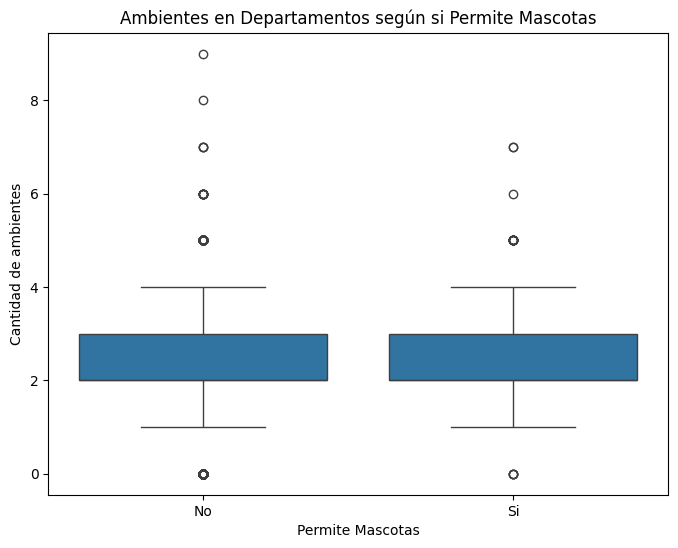

In [138]:

# Filtrar solo departamentos y limpiar texto en columnas
df_deptos = df[df['TIPO'].str.strip().str.capitalize() == 'Departamento'].copy()
df_deptos['permite_mascotas'] = df_deptos['PERMITE_MASCOTAS'].str.strip().str.capitalize()

# Gráfico de caja (boxplot) para comparar VALOR_METRO_CUADRADO
plt.figure(figsize=(8,6))
sns.boxplot(data=df_deptos, x='permite_mascotas', y='CANTIDAD_AMBIENTES')

plt.title('Ambientes en Departamentos según si Permite Mascotas')
plt.xlabel('Permite Mascotas')
plt.ylabel('Cantidad de ambientes')
plt.show()


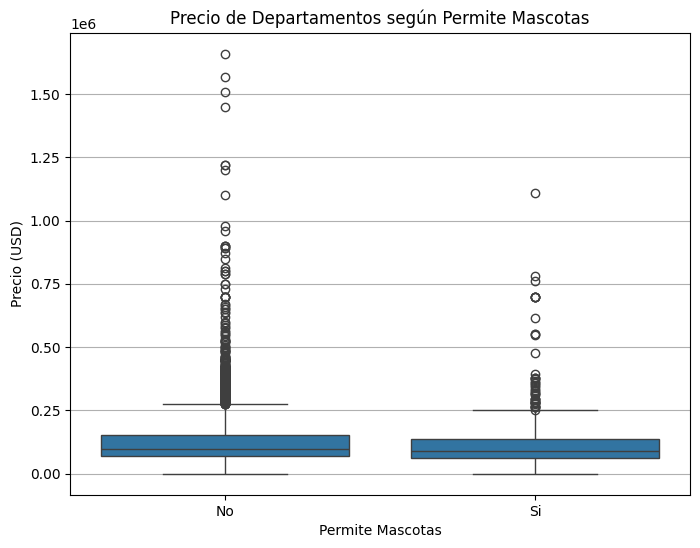

In [139]:
# Filtrar solo departamentos y 
df_deptos = df[df['TIPO'] == 'Departamento']

plt.figure(figsize=(8,6))
sns.boxplot(x='PERMITE_MASCOTAS', y='PRECIO', data=df_deptos)

plt.title('Precio de Departamentos según Permite Mascotas')
plt.xlabel('Permite Mascotas')
plt.ylabel('Precio (USD)')
plt.grid(True, axis='y')

plt.show()

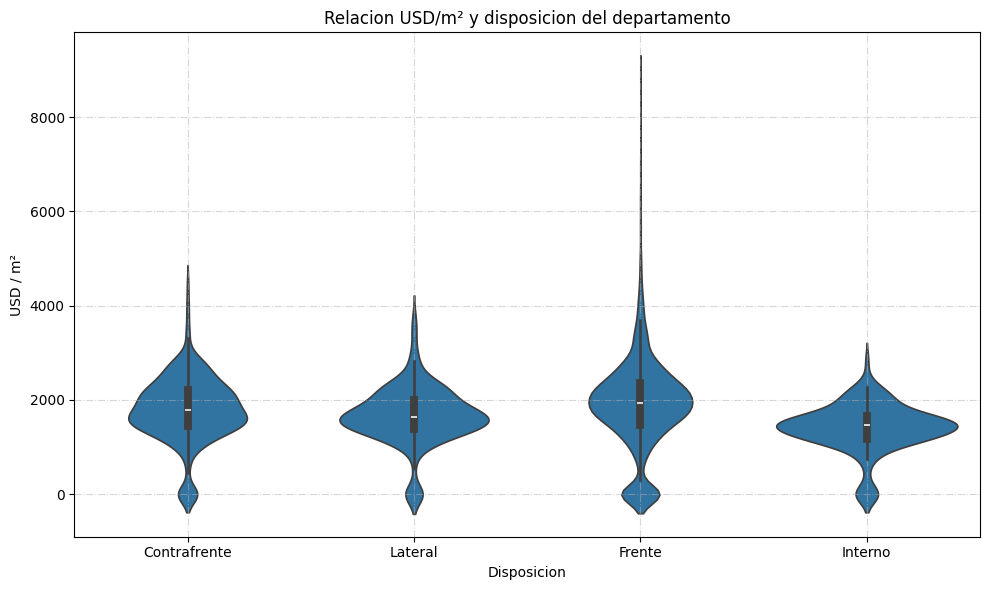

In [140]:
# Filtrar el DataFrame para excluir 'No disponible' en la columna 'DISPOSICION'
df_filtrado = df[df['DISPOSICION'] != 'No disponible']

# Crear gráfico tipo violín con el DataFrame filtrado
plt.figure(figsize=(10,6))
sns.violinplot(x='DISPOSICION', y='VALOR_METRO_CUADRADO', data=df_filtrado)

plt.title('Relacion USD/m² y disposicion del departamento')
plt.xlabel('Disposicion')
plt.ylabel('USD / m²')
plt.grid(True, linestyle='-.', alpha=0.5)
plt.tight_layout()
plt.show()


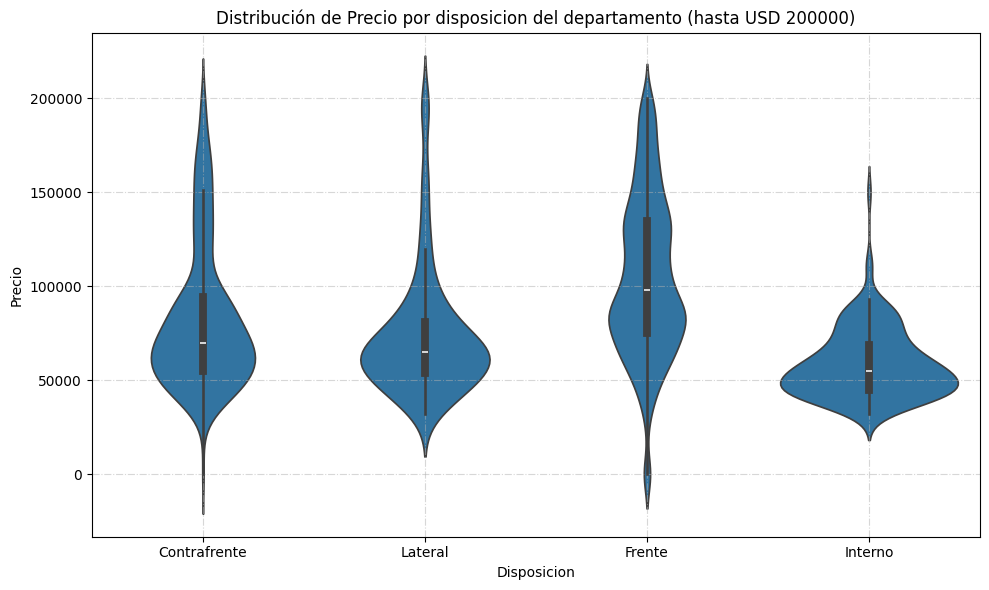

In [141]:
# Filtrar el DataFrame para excluir 'No disponible' y precios mayores a 100000
df_filtrado = df[(df['DISPOSICION'] != 'No disponible') & (df['PRECIO'] <= 200000)]

# Crear gráfico tipo violín con el DataFrame filtrado
plt.figure(figsize=(10,6))
sns.violinplot(x='DISPOSICION', y='PRECIO', data=df_filtrado)

plt.title('Distribución de Precio por disposicion del departamento (hasta USD 200000)')
plt.xlabel('Disposicion')
plt.ylabel('Precio')
plt.grid(True, linestyle='-.', alpha=0.5)
plt.tight_layout()
plt.show()


## 4 - Conclusiónes ##

In [142]:
from IPython.display import HTML

html_conclusiones = """
<h2>Conclusiones</h2>

<ol>
  <li><strong>Según tipo de inmueble:</strong>
    <ul>
      <li>La relación precio por metro cuadrado es más eficiente en casas que en departamentos, pero el precio promedio total de una casa es mayor que el de un departamento.</li>
      <li>Las casas muestran una mayor dispersión en los precios debido a la presencia de inmuebles de alta gama, como mansiones y chalets, que actúan como valores atípicos (outliers) y elevan la variabilidad del conjunto de datos.</li>
    </ul>
  </li>

  <li><strong>Según la ubicación:</strong>
    <ul>
      <li>Barrios como Playa Chica y Playa Grande presentan un alto valor por metro cuadrado, debido a que se encuentran ubicados en una zona costera turística.</li>
      <li>Se observa una dispersión de precios, lo que refleja un mercado inmobiliario heterogéneo en Mar del Plata, con barrios muy valorizados y otros con acceso más económico.</li>
      <li>El barrio con el precio promedio más alto no siempre tiene el mayor conteo de inmuebles disponibles, lo que sugiere que la oferta en zonas exclusivas es más limitada y selectiva, como el caso de Los Troncos.</li>
      <li>Barrios con precios moderados presentan un mayor conteo de inmuebles, indicando que son áreas urbanas con mayor disponibilidad.</li>
    </ul>
  </li>

  <li><strong>Según la antigüedad:</strong>
    <ul>
      <li>No se presenta una diferencia significativa promedio entre casa y departamento y dispersión de datos; sin embargo, las casas tienden a presentar una antigüedad ligeramente mayor.</li>
    </ul>
  </li>

  <li><strong>Según si permite mascotas:</strong>
    <ul>
      <li>Considerando solamente los departamentos, tras considerar por defecto a los datos no disponibles para este campo como “No permite mascota”, se observa una baja cantidad de departamentos que sí permiten.</li>
      <li>No se aprecia una diferencia significativa entre los departamentos que sí aceptan mascotas con los que no permiten.</li>
    </ul>
  </li>

  <li><strong>Según disposición:</strong>
    <ul>
      <li>Los departamentos con disposición Frente tienden a tener un precio por metro cuadrado más alto, mientras que los de disposición Interno tienden a un menor precio.</li>
      <li>La disposición Frente muestra una mayor variabilidad y un rango más amplio de precios, indicando que puede haber departamentos de muy diferentes características.</li>
      <li>Las disposiciones Contrafrente y Lateral tienen distribuciones relativamente homogéneas y similares entre sí.</li>
    </ul>
  </li>
</ol>
"""

HTML(html_conclusiones)
